# O Impacto do Contexto Histórico e da Indústria de Jogos na Escolha de Hardware dos Usuários da Steam

**Integrantes:** [Caio Paiva](https://github.com/caiopaiva92), [João Arnaud](https://github.com/JoaoArnaud), [Eduardo Antônio](https://github.com/EduardoLeitaoFilho) e [Thiago Lacerda](https://github.com/Thiago-S-Lacerda)

**Disciplina:** Introdução à Ciência de Dados — Projeto Final

---

Este notebook reúne, em um único relatório, todas as etapas do projeto: **Extração** dos dados brutos da pesquisa *Steam Hardware & Software Survey*, **Leitura** e unificação dos arquivos coletados, **Limpeza** dos dados e, por fim, os **Gráficos** e modelos (regressão linear e agrupamento com K-Means) usados para responder às perguntas do projeto. O documento termina com uma comparação entre as tendências encontradas e as especificações reais da **Steam Machine (2026)** da Valve, seguida da conclusão.

## Introdução

### Motivação
A Steam divulga mensalmente o **Steam Hardware & Software Survey**, uma pesquisa com a configuração de hardware e software de milhões de usuários da plataforma. Esses dados formam um retrato de como o parque de computadores gamers evolui ano a ano, refletindo o lançamento de novos jogos, consoles, GPUs e mudanças de sistema operacional. Nosso grupo se interessou em entender como esse hardware mudou entre 2019 e 2026, e o que essas tendências sugerem sobre o futuro próximo (até 2030) — inclusive comparando com um produto real que acabou de chegar ao mercado, a Steam Machine da Valve.

### Objetivo geral
Analisar a evolução de características de hardware e software (RAM, VRAM, CPU, GPU, sistema operacional e resolução de tela) dos usuários da Steam ao longo do tempo, relacionando essas mudanças ao contexto histórico e à indústria de jogos, e usar modelos estatísticos simples para projetar tendências futuras.

### Perguntas a serem respondidas
1. Como a distribuição da quantidade de memória RAM instalada mudou entre 2019 e 2026, e qual a projeção para 2030 (regressão linear)?
2. Como evoluiu a distribuição de VRAM ao longo dos anos? É possível separar os usuários em perfis de hardware (entrada, intermediário, entusiasta) via **agrupamento (K-Means)**, e como esses perfis evoluíram?
3. Como o número de núcleos/CPUs físicas relatado pelos usuários evoluiu, e qual configuração deve predominar em 2030?
4. A transição de Windows 10 para Windows 11 já está consolidada? Como isso variou mês a mês em 2025 e 2026 visto o fim do suporte ao Windows 10 pela Microsoft?
5. Linux e macOS estão ganhando espaço frente ao Windows na plataforma Steam?
6. Qual a participação de mercado de NVIDIA, AMD e Intel entre as placas de vídeo reportadas, e como ela mudou ao longo dos anos?
7. Qual a resolução mais popular entre os usuários e qual o cenário atual de crescimento e decrescimento desse hardware?
8. Existe correlação entre a queda de participação do Windows 10 e o crescimento do Windows 11 (matriz de correlação)?
9. As especificações de hardware da Steam Machine (2026), lançada pela Valve, condizem com o hardware "mediano" projetado pelos nossos modelos para 2026? E para os anos posteriores?

### Dados usados
Os dados vêm do **Steam Hardware & Software Survey**, coletados por *web scraping* de snapshots mensais arquivados no Wayback Machine, entre janeiro de 2019 e maio de 2026. As categorias analisadas são:

| Categoria | Descrição |
| --- | --- |
| `OS Version` | Sistemas operacionais e versões usados pelos usuários. |
| `System RAM` | Quantidade de memória RAM instalada. |
| `Physical CPUs` | Quantidade de núcleos/CPUs físicas reportados. |
| `Video Card Description` | Modelos de placas de vídeo. |
| `VRAM` | Quantidade de memória de vídeo. |
| `Primary Display Resolution` | Resolução principal de tela. |

Cada snapshot mensal gerou um registro com `Categoria`, `Especificação`, a `Porcentagens` de usuários e a variação (`Incrementos/Decrementos`) em relação ao mês anterior. A partir dos arquivos mensais (8 anos, de 2019 a maio de 2026), também construímos uma versão **anual** de referência, usando dezembro (ou o último mês disponível) como valor final do ano.

Este relatório está organizado nas seguintes etapas, cada uma correspondendo aos notebooks originais do projeto: **Extração → Leitura → Limpeza → Gráficos**, seguido da comparação com a Steam Machine e da conclusão.

## Extração

Nesta etapa os dados brutos são coletados diretamente do site da Steam, através de *snapshots* arquivados no Wayback Machine, e depois agregados em uma versão anual.

> ⚠️ **As células de coleta abaixo não devem ser executadas novamente.** Elas fazem requisições HTTP ao Wayback Machine (com `time.sleep(5)` entre cada uma) e já foram executadas uma única vez para gerar os arquivos que estão salvos em `CSVs/Mensais/` e `CSVs/Anuais/`. Elas estão aqui apenas como documentação do processo de coleta.

### 1. Extração mensal (web scraping)
Notebook original: `Extração_dos_Dados/Extração_mensal_todos_os_anos.ipynb`

* <h3>FUNÇÃO CSV_CREATOR:</h3>

Essa função, como o nome já diz, cria um csv. Ela pega cada uma das linhas dos dados de hardware da steam, através do método scraping. Através dos ids, ele sempre pega as mesmas linhas em cada um dos meses e escreve linha por linha no arquivo que ele próprio cria, se não existir esse arquivo no computador. Ela recebe uma lista de tuplas com o link referente ao mês, exemplo: [("link", "Janeiro"), ("link", "Fevereiro"), ...]. Com essa lista, ela percorre cada um dos links para pegar todos os meses do ano de uma só vez.

In [1]:
import time
import requests
from bs4 import BeautifulSoup

In [3]:
def csv_creator(links_meses, ano):
    ids_categorias = [('osversion_details', 'OS Version'), ('cat0_details', 'System RAM'), ('cat2_details', 'Physical CPUs'), ('cat3_details', 'Video Card Description'), ('cat4_details', 'VRAM'), ('cat5_details', 'Primary Display Resolution')]

    with open(f'dados_mensais_{ano}.csv', 'w', encoding='utf-8') as f:
                f.write('Categoria, Especificação, Porcentagens, Incrementos/Decrementos, Mês, Ano\n')

    for link, mes in links_meses:
        time.sleep(5)
        html = requests.get(link).text
        soup = BeautifulSoup(html, 'html.parser')

        for id_, categoria in ids_categorias:
            # Pega apenas a div do id especificado (Os ids tem que ser os details para funcionar)
            div = soup.find('div', id=f'{id_}')

            titulos = div.find_all('div', class_='stats_col_mid')
            porcentagens = div.find_all('div', class_='stats_col_right')
            incs_decs = div.find_all('div', class_='stats_col_right2')

            with open(f'dados_mensais_{ano}.csv', 'a+', encoding='utf-8') as f:
                for titulo, porcentagem, inc_dec in zip(titulos, porcentagens, incs_decs):
                    f.write(f"{categoria}, {titulo.text.strip()}, {porcentagem.text.strip()}, {inc_dec.text.strip()}, {mes}, {ano}\n")


###### Arquivo usado para chamar a função referente ao ano de 2019:

In [ ]:
links_mes_2019 = [('https://web.archive.org/web/20190203085600/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Janeiro'), 
           ('https://web.archive.org/web/20190322155105/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Fevereiro'), 
           ('https://web.archive.org/web/20190417153349/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Março'), 
           ('https://web.archive.org/web/20190513072058/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Abril'), 
           ('https://web.archive.org/web/20190616163322/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Maio'), 
           ('https://web.archive.org/web/20190703191628/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Junho'), 
           ('https://web.archive.org/web/20190830001952/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Julho'), 
           ('https://web.archive.org/web/20190906194713/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Agosto'), 
           ('https://web.archive.org/web/20191010085406/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Setembro'), 
           ('https://web.archive.org/web/20191102081710/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Outubro'), 
           ('https://web.archive.org/web/20191209230538/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Novembro'), 
           ('https://web.archive.org/web/20200121101548/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Dezembro')]

csv_creator(links_mes_2019, 2019)

###### Arquivo usado para chamar a função referente ao ano de 2020:

O de 2020 está faltando o mês de junho, pois no site utilizado não tinha como pegar o link de junho

In [ ]:
links_mes_2020 = [('https://web.archive.org/web/20200202095248/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Janeiro'), 
           ('https://web.archive.org/web/20200316152704/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Fevereiro'), 
           ('https://web.archive.org/web/20200407072208/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Março'), 
           ('https://web.archive.org/web/20200505150638/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Abril'), 
           ('https://web.archive.org/web/20200608014405/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Maio'), 
           ('https://web.archive.org/web/20200808140607/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Julho'), 
           ('https://web.archive.org/web/20200908144606/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Agosto'), 
           ('https://web.archive.org/web/20201009143637/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Setembro'), 
           ('https://web.archive.org/web/20201104192639/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Outubro'), 
           ('https://web.archive.org/web/20201209234627/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Novembro'), 
           ('https://web.archive.org/web/20210105073410/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam', 'Dezembro')]

csv_creator(links_mes_2020, 2020)

#### Busca dos dados de Junho de 2020

###### Os dados desse mês não estão no site utilizado, então usaremos um CSV já "pronto". Entretanto, os dados desse CSV não estão no mesmo formato do CSV criado pelo csv_creator. Então precisamos padronizá-lo para encaixar junto ao nosso

* Importação da bibilioteca Pandas

In [16]:
import pandas as pd

* Leitura do CSV pronto da internet

In [17]:
df = pd.read_csv('junho_2020.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        193 non-null    str    
 1   category    193 non-null    str    
 2   name        192 non-null    str    
 3   change      193 non-null    float64
 4   percentage  193 non-null    float64
dtypes: float64(2), str(3)
memory usage: 7.7 KB


,date,category,name,change,percentage
0,2020-06-01,OS Version,"""Arch Linux"" 64 bit",0.0000,0.0010
1,2020-06-01,OS Version,"""Manjaro Linux"" 64 bit",0.0000,0.0010
2,2020-06-01,OS Version,Linux Mint 19.3 Tricia 64 bit,0.0000,0.0007
3,2020-06-01,OS Version,MacOS 10.11.6 64 bit,-0.0002,0.0012
4,2020-06-01,OS Version,MacOS 10.12.6 64 bit,-0.0003,0.0016


* Deletando a coluna "date", já que não usamos nesse formato de data

In [18]:
df.drop('date', axis=1, inplace=True)
df

,category,name,change,percentage
0,OS Version,"""Arch Linux"" 64 bit",0.0000,0.0010
1,OS Version,"""Manjaro Linux"" 64 bit",0.0000,0.0010
2,OS Version,Linux Mint 19.3 Tricia 64 bit,0.0000,0.0007
3,OS Version,MacOS 10.11.6 64 bit,-0.0002,0.0012
4,OS Version,MacOS 10.12.6 64 bit,-0.0003,0.0016
...,...,...,...,...
188,Primary Display Resolution,2560 x 1080,0.0000,0.0113
189,Primary Display Resolution,2560 x 1440,0.0017,0.0623
190,Primary Display Resolution,3440 x 1440,0.0005,0.0087
191,Primary Display Resolution,3840 x 2160,-0.0005,0.0212


* Renomeando as colunas para ficar igual ao padrão do csv_creator

In [19]:
colunas = {'category': 'Categoria', 'name': 'Especificação', 'change': 'Incrementos/Decrementos', 'percentage': 'Porcentagens'}

df = df.rename(columns=colunas)
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                193 non-null    str    
 1   Especificação            192 non-null    str    
 2   Incrementos/Decrementos  193 non-null    float64
 3   Porcentagens             193 non-null    float64
dtypes: float64(2), str(2)
memory usage: 6.2 KB


,Categoria,Especificação,Incrementos/Decrementos,Porcentagens
0,OS Version,"""Arch Linux"" 64 bit",0.0000,0.0010
1,OS Version,"""Manjaro Linux"" 64 bit",0.0000,0.0010
2,OS Version,Linux Mint 19.3 Tricia 64 bit,0.0000,0.0007
3,OS Version,MacOS 10.11.6 64 bit,-0.0002,0.0012
4,OS Version,MacOS 10.12.6 64 bit,-0.0003,0.0016


* As porcentagens desse CSV estão no valor literal delas e não em formato de porcentagem. Por isso, precisamos multiplicar o valor por 100 em cada linha e arredondar para 2 casas decimais para ficar igual ao padrão do csv_creator

In [20]:
colunas_porcentagem = ['Incrementos/Decrementos', 'Porcentagens']
df[colunas_porcentagem] = (df[colunas_porcentagem] * 100).round(2)
df.head()

,Categoria,Especificação,Incrementos/Decrementos,Porcentagens
0,OS Version,"""Arch Linux"" 64 bit",0.00,0.10
1,OS Version,"""Manjaro Linux"" 64 bit",0.00,0.10
2,OS Version,Linux Mint 19.3 Tricia 64 bit,0.00,0.07
3,OS Version,MacOS 10.11.6 64 bit,-0.02,0.12
4,OS Version,MacOS 10.12.6 64 bit,-0.03,0.16


* Alterando a ordem das colunas para ficar no mesmo padrão

In [21]:
ordem_colunas = ['Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos']
df = df[ordem_colunas]
df.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos
0,OS Version,"""Arch Linux"" 64 bit",0.10,0.00
1,OS Version,"""Manjaro Linux"" 64 bit",0.10,0.00
2,OS Version,Linux Mint 19.3 Tricia 64 bit,0.07,0.00
3,OS Version,MacOS 10.11.6 64 bit,0.12,-0.02
4,OS Version,MacOS 10.12.6 64 bit,0.16,-0.03


* Adicionando as colunas restantes que faltam referentes ao mês e ano

In [ ]:
df['Mês'] = 'Junho'
df['Ano'] = 2020
df.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
0,OS Version,"""Arch Linux"" 64 bit",0.10,0.00,Junho,2020
1,OS Version,"""Manjaro Linux"" 64 bit",0.10,0.00,Junho,2020
2,OS Version,Linux Mint 19.3 Tricia 64 bit,0.07,0.00,Junho,2020
3,OS Version,MacOS 10.11.6 64 bit,0.12,-0.02,Junho,2020
4,OS Version,MacOS 10.12.6 64 bit,0.16,-0.03,Junho,2020


* Voltando para o formato de CSV

In [26]:
ARQUIVO_SAIDA = 'junho_corrijido_2020.csv'

df.to_csv(ARQUIVO_SAIDA, index=False)

Depois de transformar num CSV, apenas copiei e colei no arquivo: "dados_mensais_2020.csv"

###### Arquivo usado para chamar a função referente ao ano de 2021:

In [ ]:
links_2021 = [
    ("https://web.archive.org/web/20210211165325/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Janeiro"),
    ("https://web.archive.org/web/20210310013538/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Fevereiro"),
    ("https://web.archive.org/web/20210406145322/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Março"),
    ("https://web.archive.org/web/20210507144019/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Abril"),
    ("https://web.archive.org/web/20210612115956/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Maio"),
    ("https://web.archive.org/web/20210711092307/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Junho"),
    ("https://web.archive.org/web/20210810140809/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Julho"),
    ("https://web.archive.org/web/20210913120919/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Agosto"),
    ("https://web.archive.org/web/20211019145205/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Setembro"),
    ("https://web.archive.org/web/20211103003851/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Outubro"),
    ("https://web.archive.org/web/20211215004809/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Novembro"),
    ("https://web.archive.org/web/20220105105617/https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam", "Dezembro")
]

csv_creator(links_2021, 2021)

###### Arquivo usado para chamar a função referente ao ano de 2022:

In [5]:
links_mes_2022 = [
    ("https://web.archive.org/web/20220216223201/https://store.steampowered.com/hwsurvey/", "Janeiro"),
    ("https://web.archive.org/web/20220308233319/https://store.steampowered.com/hwsurvey/", "Fevereiro"),
    ("https://web.archive.org/web/20220402235914/https://store.steampowered.com/hwsurvey/", "Março"),
    ("https://web.archive.org/web/20220503173516/https://store.steampowered.com/hwsurvey/", "Abril"),
    ("https://web.archive.org/web/20220603173703/https://store.steampowered.com/hwsurvey/", "Maio"),
    ("https://web.archive.org/web/20220703080035/https://store.steampowered.com/hwsurvey/", "Junho"),
    ("https://web.archive.org/web/20220803214815/https://store.steampowered.com/hwsurvey/", "Julho"),
    ("https://web.archive.org/web/20220903174209/https://store.steampowered.com/hwsurvey/", "Agosto"),
    ("https://web.archive.org/web/20221006180352/https://store.steampowered.com/hwsurvey/", "Setembro"),
    ("https://web.archive.org/web/20221104235848/https://store.steampowered.com/hwsurvey/", "Outubro"),
    ("https://web.archive.org/web/20221203055418/https://store.steampowered.com/hwsurvey/", "Novembro"),
    ("https://web.archive.org/web/20230104022312/https://store.steampowered.com/hwsurvey/", "Dezembro")
]

csv_creator(links_mes_2022, 2022)

###### Arquivo usado para chamar a função referente ao ano de 2023:

In [ ]:
links_mes_2023 = [
    ('https://web.archive.org/web/20230223130822/https://store.steampowered.com/hwsurvey', 'Janeiro'),
    ('https://web.archive.org/web/20230324031020/https://store.steampowered.com/hwsurvey', 'Fevereiro'),
    ('https://web.archive.org/web/20230427200029/https://store.steampowered.com/hwsurvey/', 'Março'),
    ('https://web.archive.org/web/20230520184615/https://store.steampowered.com/hwsurvey', 'Abril'),
    ('https://web.archive.org/web/20230621110526/https://store.steampowered.com/hwsurvey', 'Maio'),
    ('https://web.archive.org/web/20230726080827/https://store.steampowered.com/hwsurvey/', 'Junho'),
    ('https://web.archive.org/web/20230827005012/https://store.steampowered.com/hwsurvey', 'Julho'),
    ('https://web.archive.org/web/20230925072910/https://store.steampowered.com/hwsurvey/', 'Agosto'),
    ('https://web.archive.org/web/20231025033018/https://store.steampowered.com/hwsurvey/', 'Setembro'),
    ('https://web.archive.org/web/20231123010539/https://store.steampowered.com/hwsurvey/', 'Outubro'),
    ('https://web.archive.org/web/20231223154008/https://store.steampowered.com/hwsurvey', 'Novembro'),
    ('https://web.archive.org/web/20240118111931/https://store.steampowered.com/hwsurvey', 'Dezembro')
]

csv_creator(links_mes_2023, 2023)

###### Arquivo usado para chamar a função referente ao ano de 2024:

In [ ]:
links_mes_2024 = [
    ('https://web.archive.org/web/20240222222446/https://store.steampowered.com/hwsurvey', 'Janeiro'),
    ('https://web.archive.org/web/20240321031400/https://store.steampowered.com/hwsurvey/', 'Fevereiro'),
    ('https://web.archive.org/web/20240418143723/https://store.steampowered.com/hwsurvey', 'Março'),
    ('https://web.archive.org/web/20240523175529/https://store.steampowered.com/hwsurvey/', 'Abril'),
    ('https://web.archive.org/web/20240621130112/https://store.steampowered.com/hwsurvey/', 'Maio'),
    ('https://web.archive.org/web/20240727073021/https://store.steampowered.com/hwsurvey/', 'Junho'),
    ('https://web.archive.org/web/20240823185528/https://store.steampowered.com/hwsurvey/', 'Julho'),
    ('https://web.archive.org/web/20240925062001/https://store.steampowered.com/hwsurvey/', 'Agosto'),
    ('https://web.archive.org/web/20241023163048/https://store.steampowered.com/hwsurvey', 'Setembro'),
    ('https://web.archive.org/web/20241123003845/https://store.steampowered.com/hwsurvey/', 'Outubro'),
    ('https://web.archive.org/web/20241226190453/https://store.steampowered.com/hwsurvey/', 'Novembro'),
    ('https://web.archive.org/web/20250123170629/https://store.steampowered.com/hwsurvey/', 'Dezembro')
]

csv_creator(links_mes_2024, 2024)

###### Arquivo usado para chamar a função referente ao ano de 2025:

In [ ]:
links_mes_2025 = [
    ('https://web.archive.org/web/20250220123300/https://store.steampowered.com/hwsurvey', 'Janeiro'),
    ('https://web.archive.org/web/20250321095337/https://store.steampowered.com/hwsurvey', 'Fevereiro'),
    ('https://web.archive.org/web/20250421105211/https://store.steampowered.com/hwsurvey', 'Março'),
    ('https://web.archive.org/web/20250520054016/https://store.steampowered.com/hwsurvey', 'Abril'),
    ('https://web.archive.org/web/20250620212251/https://store.steampowered.com/hwsurvey', 'Maio'),
    ('https://web.archive.org/web/20250720135921/https://store.steampowered.com/hwsurvey', 'Junho'),
    ('https://web.archive.org/web/20250820191650/https://store.steampowered.com/hwsurvey', 'Julho'),
    ('https://web.archive.org/web/20250920044413/https://store.steampowered.com/hwsurvey', 'Agosto'),
    ('https://web.archive.org/web/20251021102446/https://store.steampowered.com/hwsurvey', 'Setembro'),
    ('https://web.archive.org/web/20251121052510/https://store.steampowered.com/hwsurvey', 'Outubro'),
    ('https://web.archive.org/web/20251220102808/https://store.steampowered.com/hwsurvey', 'Novembro'),
    ('https://web.archive.org/web/20260120232030/https://store.steampowered.com/hwsurvey', 'Dezembro')
]

csv_creator(links_mes_2025, 2025)

###### Arquivo usado para chamar a função referente ao ano de 2026:

In [ ]:
links_mes_2026 = [
    ('https://web.archive.org/web/20260220193758/https://store.steampowered.com/hwsurvey', 'Janeiro'),
    ('https://web.archive.org/web/20260319195120/https://store.steampowered.com/hwsurvey', 'Fevereiro'),
    ('https://web.archive.org/web/20260421031448/https://store.steampowered.com/hwsurvey', 'Março'),
    ('https://web.archive.org/web/20260520195334/https://store.steampowered.com/hwsurvey', 'Abril'),
    ('https://web.archive.org/web/20260622184908/https://store.steampowered.com/hwsurvey', 'Maio')
]

csv_creator(links_mes_2026, 2026)

### 2. Extração anual (agregação de mensal para anual)
Notebook original: `Extração_dos_Dados/Extração_anual_todos_os_anos.ipynb`

Para cada ano, o valor anual de cada especificação é o percentual de dezembro (ou do último mês disponível, no caso de 2026), e o incremento anual é a diferença entre esse valor final e o valor da primeira aparição da especificação naquele ano — isso evita distorções quando uma peça só passa a existir na pesquisa no meio do ano.

#### Extração de dados anuais da Steam

###### Import da biblioteca pandas:

In [19]:
import pandas as pd

###### Leitura dos arquivos

In [20]:
df_2019 = pd.read_csv("CSVs/Mensais/dados_mensais_2019.csv")
df_2020 = pd.read_csv("CSVs/Mensais/dados_mensais_2020.csv")
df_2021 = pd.read_csv("CSVs/Mensais/dados_mensais_2021.csv")
df_2022 = pd.read_csv("CSVs/Mensais/dados_mensais_2022.csv")
df_2023 = pd.read_csv("CSVs/Mensais/dados_mensais_2023.csv")
df_2024 = pd.read_csv("CSVs/Mensais/dados_mensais_2024.csv")
df_2025 = pd.read_csv("CSVs/Mensais/dados_mensais_2025.csv")
df_2026 = pd.read_csv("CSVs/Mensais/dados_mensais_2026.csv")

### Criação dos dados anuais

#### Limpeza e conversão de tipos

##### Remover espaço vazio a esquerda das colunas

In [21]:
df_2019.columns = df_2019.columns.str.lstrip()
df_2020.columns = df_2020.columns.str.lstrip()
df_2021.columns = df_2021.columns.str.lstrip()
df_2022.columns = df_2022.columns.str.lstrip()
df_2023.columns = df_2023.columns.str.lstrip()
df_2024.columns = df_2024.columns.str.lstrip()
df_2025.columns = df_2025.columns.str.lstrip()
df_2026.columns = df_2026.columns.str.lstrip()

##### Remoção dos espaços a esquerda dos valores da coluna mês

In [22]:
df_2019['Mês'] = df_2019['Mês'].astype(str).str.lstrip()
df_2020['Mês'] = df_2020['Mês'].astype(str).str.lstrip()
df_2021['Mês'] = df_2021['Mês'].astype(str).str.lstrip()
df_2022['Mês'] = df_2022['Mês'].astype(str).str.lstrip()
df_2023['Mês'] = df_2023['Mês'].astype(str).str.lstrip()
df_2024['Mês'] = df_2024['Mês'].astype(str).str.lstrip()
df_2025['Mês'] = df_2025['Mês'].astype(str).str.lstrip()
df_2026['Mês'] = df_2026['Mês'].astype(str).str.lstrip()

##### Conversão de incremento e porcentagem para float

In [23]:
df_2019['Porcentagens'] = (df_2019['Porcentagens'].str.replace('%', '', regex=False).str.strip().astype(float))
df_2019['Incrementos/Decrementos'] = (df_2019['Incrementos/Decrementos'].str.replace('%', '', regex=False).str.strip().astype(float))

df_2020['Porcentagens'] = (df_2020['Porcentagens'].str.replace('%', '', regex=False).str.strip().astype(float))
df_2020['Incrementos/Decrementos'] = (df_2020['Incrementos/Decrementos'].str.replace('%', '', regex=False).str.strip().astype(float))

df_2021['Porcentagens'] = (df_2021['Porcentagens'].str.replace('%', '', regex=False).str.strip().astype(float))
df_2021['Incrementos/Decrementos'] = (df_2021['Incrementos/Decrementos'].str.replace('%', '', regex=False).str.strip().astype(float))

df_2022['Porcentagens'] = (df_2022['Porcentagens'].str.replace('%', '', regex=False).str.strip().astype(float))
df_2022['Incrementos/Decrementos'] = (df_2022['Incrementos/Decrementos'].str.replace('%', '', regex=False).str.strip().astype(float))

df_2023['Porcentagens'] = (df_2023['Porcentagens'].str.replace('%', '', regex=False).str.strip().astype(float))
df_2023['Incrementos/Decrementos'] = (df_2023['Incrementos/Decrementos'].str.replace('%', '', regex=False).str.strip().astype(float))

df_2024['Porcentagens'] = (df_2024['Porcentagens'].str.replace('%', '', regex=False).str.strip().astype(float))
df_2024['Incrementos/Decrementos'] = (df_2024['Incrementos/Decrementos'].str.replace('%', '', regex=False).str.strip().astype(float))

df_2025['Porcentagens'] = (df_2025['Porcentagens'].str.replace('%', '', regex=False).str.strip().astype(float))
df_2025['Incrementos/Decrementos'] = (df_2025['Incrementos/Decrementos'].str.replace('%', '', regex=False).str.strip().astype(float))

df_2026['Porcentagens'] = (df_2026['Porcentagens'].str.replace('%', '', regex=False).str.strip().astype(float))
df_2026['Incrementos/Decrementos'] = (df_2026['Incrementos/Decrementos'].str.replace('%', '', regex=False).str.strip().astype(float))

- Verificação dos tipos:

In [24]:
print(df_2021.dtypes)

Categoria                      str
Especificação                  str
Porcentagens               float64
Incrementos/Decrementos    float64
Mês                            str
Ano                          int64
dtype: object


#### Criação dos valores anuais.

Para criar os valores anuais pegaremos os valores de Dezembro como referência e subtrairemos pelos valores da primeira aparição daquela especificação ao longo dos meses daquele ano evitando o erro de peças que estão em dezembro mas não aparecem necessariamente em janeiro. Para 2026, como ainda não existem todos os meses, usamos Maio como referência final disponível.

- Pegando apenas os dados de dezembro

In [25]:
dezembro_2019 = (
    df_2019[df_2019['Mês'] == 'Dezembro']
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2020 = (
    df_2020[df_2020['Mês'] == 'Dezembro']
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2021 = (
    df_2021[df_2021['Mês'] == 'Dezembro']
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2022 = (
    df_2022[df_2022['Mês'] == 'Dezembro']
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2023 = (
    df_2023[df_2023['Mês'] == 'Dezembro']
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2024 = (
    df_2024[df_2024['Mês'] == 'Dezembro']
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2025 = (
    df_2025[df_2025['Mês'] == 'Dezembro']
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

maio_2026 = (
    df_2026[df_2026['Mês'] == 'Maio']
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

- Verificação do DataFrame:

In [26]:
print(f"Registros em Dezembro: {len(dezembro_2021)}")
dezembro_2021.head()

Registros em Dezembro: 202


,Ano,Categoria,Especificação,Porcentagens
2118,2021,OS Version,Windows,96.19
2119,2021,OS Version,Windows 10 64 bit,81.74
2120,2021,OS Version,Windows 11 64 bit,10.15
2121,2021,OS Version,Windows 7 64 bit,3.24
2122,2021,OS Version,Windows 8.1 64 bit,0.68


- Pegando a primeira aparição

O groupby agrupa os dados e pega a primeira linha de cada grupo

In [27]:
primeira_2019 = (df_2019.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2020 = (df_2020.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2021 = (df_2021.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)
primeira_2022 = (df_2022.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2023 = (df_2023.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2024 = (df_2024.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2025 = (df_2025.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2026 = (df_2026.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

- União dos meses

O merge faz a união dos dois datasets a partir das chaves ano, categoria e especificação

In [28]:
resultado_2019 = pd.merge(dezembro_2019,primeira_2019,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2019['Incrementos/Decrementos'] = (resultado_2019['Porcentagens'] - resultado_2019['Porcentagem_Inicial']).round(2)

resultado_2020 = pd.merge(dezembro_2020,primeira_2020,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2020['Incrementos/Decrementos'] = (resultado_2020['Porcentagens'] - resultado_2020['Porcentagem_Inicial']).round(2)

resultado_2021 = pd.merge(dezembro_2021,primeira_2021,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2021['Incrementos/Decrementos'] = (resultado_2021['Porcentagens'] - resultado_2021['Porcentagem_Inicial']).round(2)

resultado_2022 = pd.merge(dezembro_2022,primeira_2022,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2022['Incrementos/Decrementos'] = (resultado_2022['Porcentagens'] - resultado_2022['Porcentagem_Inicial']).round(2)

resultado_2023 = pd.merge(dezembro_2023,primeira_2023,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2023['Incrementos/Decrementos'] = (resultado_2023['Porcentagens'] - resultado_2023['Porcentagem_Inicial']).round(2)

resultado_2024 = pd.merge(dezembro_2024,primeira_2024,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2024['Incrementos/Decrementos'] = (resultado_2024['Porcentagens'] - resultado_2024['Porcentagem_Inicial']).round(2)

resultado_2025 = pd.merge(dezembro_2025,primeira_2025,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2025['Incrementos/Decrementos'] = (resultado_2025['Porcentagens'] - resultado_2025['Porcentagem_Inicial']).round(2)

resultado_2026 = pd.merge(maio_2026,primeira_2026,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2026['Incrementos/Decrementos'] = (resultado_2026['Porcentagens'] - resultado_2026['Porcentagem_Inicial']).round(2)

- Criação do csv

A variável CSV final serve pra ignorar algumas colunas que foram criadas e deixar no formato dos dados mensais mas sem a coluna mês

In [29]:
csv_final = resultado_2019[[
    'Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos',
    'Ano'
]]

ARQUIVO_SAIDA_2019 = 'CSVs/Anuais/dados_anuais_2019.csv'

csv_final.to_csv(ARQUIVO_SAIDA_2019, index=False)

In [30]:
csv_final = resultado_2020[[
    'Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos',
    'Ano'
]]

ARQUIVO_SAIDA_2020 = 'CSVs/Anuais/dados_anuais_2020.csv'

csv_final.to_csv(ARQUIVO_SAIDA_2020, index=False)

In [31]:
csv_final = resultado_2021[[
    'Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos',
    'Ano'
]]

ARQUIVO_SAIDA_2021 = 'CSVs/Anuais/dados_anuais_2021.csv'

csv_final.to_csv(ARQUIVO_SAIDA_2021, index=False)

In [32]:
csv_final = resultado_2022[[
    'Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos',
    'Ano'
]]

ARQUIVO_SAIDA_2022 = 'CSVs/Anuais/dados_anuais_2022.csv'

csv_final.to_csv(ARQUIVO_SAIDA_2022, index=False)

In [33]:
csv_final = resultado_2023[[
    'Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos',
    'Ano'
]]

ARQUIVO_SAIDA_2023 = 'CSVs/Anuais/dados_anuais_2023.csv'

csv_final.to_csv(ARQUIVO_SAIDA_2023, index=False)

In [34]:
csv_final = resultado_2024[[
    'Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos',
    'Ano'
]]

ARQUIVO_SAIDA_2024 = 'CSVs/Anuais/dados_anuais_2024.csv'

csv_final.to_csv(ARQUIVO_SAIDA_2024, index=False)

In [35]:
csv_final = resultado_2025[[
    'Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos',
    'Ano'
]]

ARQUIVO_SAIDA_2025 = 'CSVs/Anuais/dados_anuais_2025.csv'

csv_final.to_csv(ARQUIVO_SAIDA_2025, index=False)

In [36]:
csv_final = resultado_2026[[
    'Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos',
    'Ano'
]]

ARQUIVO_SAIDA_2026 = 'CSVs/Anuais/dados_anuais_2026.csv'

csv_final.to_csv(ARQUIVO_SAIDA_2026, index=False)

## Leitura

Depois de coletados os dados de cada ano separadamente, ficamos com um CSV por ano dentro de `CSVs/Mensais` e `CSVs/Anuais`. Esta etapa reúne todos esses arquivos em dois CSVs finais — um para os dados mensais e outro para os anuais — já ordenados cronologicamente e prontos para a limpeza.

Notebook original: `Extração_dos_Dados/União_dos_Dados.ipynb`

#### União dos Dados Mensais e Anuais

Depois de coletados os dados de cada ano separadamente pelos notebooks `Extração_mensal_todos_os_anos` e `Extração_anual_todos_os_anos`, ficamos com um CSV por ano dentro de `CSVs/Mensais` e `CSVs/Anuais`. Este notebook reúne todos esses arquivos em apenas dois CSVs finais, um para os dados mensais e outro para os dados anuais, já ordenados cronologicamente, prontos para serem usados na análise.

 ### Importação da biblioteca Pandas

In [1]:
import glob
import os
import pandas as pd

##### Diretórios de entrada e saída

Os CSVs de cada ano ficam separados em `CSVs/Mensais` e `CSVs/Anuais`, na raiz do repositório, enquanto este notebook fica dentro de `Extração_dos_Dados`. Como o diretório de trabalho do kernel muda dependendo de como o notebook é executado (pela raiz do repositório ou a partir da própria pasta do notebook), resolvemos o caminho checando se a pasta `CSVs` existe no diretório atual; se não existir, subimos um nível. Assim o notebook funciona nos dois cenários. O resultado da união é salvo em `CSVs/Dados unidos`.

In [2]:
diretorio_base = "." if os.path.isdir("CSVs") else ".."

diretorio_mensais = os.path.join(diretorio_base, "CSVs", "Mensais")
diretorio_anuais = os.path.join(diretorio_base, "CSVs", "Anuais")
diretorio_saida = os.path.join(diretorio_base, "CSVs", "Dados unidos")
os.makedirs(diretorio_saida, exist_ok=True)

##### Ordem cronológica dos meses

A coluna `Mês` guarda o nome do mês por extenso (`Janeiro`, `Fevereiro`, ...). Ordenar essa coluna diretamente resultaria numa ordem alfabética, e não cronológica. Por isso criamos um dicionário que mapeia cada mês para o seu número, usado só na hora de ordenar as linhas.

In [3]:
ORDEM_MESES = {
    "Janeiro": 1, "Fevereiro": 2, "Março": 3, "Abril": 4,
    "Maio": 5, "Junho": 6, "Julho": 7, "Agosto": 8,
    "Setembro": 9, "Outubro": 10, "Novembro": 11, "Dezembro": 12,
}

##### FUNÇÃO LER_CSV

Essa função lê um CSV de um ano e já deixa ele padronizado antes da união. Alguns arquivos foram escritos com um espaço em branco depois de cada vírgula (tanto no cabeçalho quanto nos valores), enquanto outros não têm esse espaço. O parâmetro `skipinitialspace=True` remove esse espaço já na leitura, e o `strip()` aplicado nos nomes das colunas e nos valores em texto garante que todos os arquivos fiquem no mesmo formato, evitando, por exemplo, que "Windows" e " Windows" sejam tratados como especificações diferentes.

In [4]:
def ler_csv(caminho):
    df = pd.read_csv(caminho, encoding="utf-8", skipinitialspace=True)
    df.columns = [c.strip() for c in df.columns]
    for coluna in df.select_dtypes(include=["object", "str"]).columns:
        df[coluna] = df[coluna].str.strip()
    return df

##### União dos arquivos mensais

Percorremos todos os arquivos `dados_mensais_<ano>.csv`, lemos cada um com a função `ler_csv` e concatenamos tudo em um único DataFrame. Depois, ordenamos pelo `Ano` e pela ordem cronológica do `Mês` (usando o dicionário `ORDEM_MESES`)

In [5]:
arquivos_mensais = sorted(glob.glob(os.path.join(diretorio_mensais, "dados_mensais_*.csv")))
arquivos_mensais

['..\\CSVs\\Mensais\\dados_mensais_2019.csv',
 '..\\CSVs\\Mensais\\dados_mensais_2020.csv',
 '..\\CSVs\\Mensais\\dados_mensais_2021.csv',
 '..\\CSVs\\Mensais\\dados_mensais_2022.csv',
 '..\\CSVs\\Mensais\\dados_mensais_2023.csv',
 '..\\CSVs\\Mensais\\dados_mensais_2024.csv',
 '..\\CSVs\\Mensais\\dados_mensais_2025.csv',
 '..\\CSVs\\Mensais\\dados_mensais_2026.csv']

In [6]:
df_mensal_completo = pd.concat(
    (ler_csv(arquivo) for arquivo in arquivos_mensais), ignore_index=True
)

df_mensal_completo["_ordem_mes"] = df_mensal_completo["Mês"].map(ORDEM_MESES)
df_mensal_completo = (
    df_mensal_completo.sort_values(by=["Ano", "_ordem_mes"])
    .drop(columns="_ordem_mes")
    .reset_index(drop=True)
)

df_mensal_completo.info()
df_mensal_completo.head()

<class 'pandas.DataFrame'>
RangeIndex: 17382 entries, 0 to 17381
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Categoria                17382 non-null  str  
 1   Especificação            17301 non-null  str  
 2   Porcentagens             17382 non-null  str  
 3   Incrementos/Decrementos  17382 non-null  str  
 4   Mês                      17382 non-null  str  
 5   Ano                      17382 non-null  int64
dtypes: int64(1), str(5)
memory usage: 814.9 KB


,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
0,OS Version,Windows,95.92%,+0.06%,Janeiro,2019
1,OS Version,Windows 10 64 bit,63.77%,-0.02%,Janeiro,2019
2,OS Version,Windows 7 64 bit,26.40%,+0.32%,Janeiro,2019
3,OS Version,Windows 8.1 64 bit,3.43%,-0.10%,Janeiro,2019
4,OS Version,Windows 7,1.52%,-0.09%,Janeiro,2019


* <h3>Salvando o CSV mensal unificado</h3>

In [7]:
df_mensal_completo.to_csv(
    os.path.join(diretorio_saida, "dados_mensais_unificado.csv"),
    index=False,
    encoding="utf-8",
)

##### União dos arquivos anuais

O mesmo procedimento é repetido para os arquivos `dados_anuais_<ano>.csv`, com a diferença de que a ordenação final é feita só pela coluna `Ano`, já que esses arquivos não têm a coluna `Mês`.

In [8]:
arquivos_anuais = sorted(glob.glob(os.path.join(diretorio_anuais, "dados_anuais_*.csv")))
arquivos_anuais

['..\\CSVs\\Anuais\\dados_anuais_2019.csv',
 '..\\CSVs\\Anuais\\dados_anuais_2020.csv',
 '..\\CSVs\\Anuais\\dados_anuais_2021.csv',
 '..\\CSVs\\Anuais\\dados_anuais_2022.csv',
 '..\\CSVs\\Anuais\\dados_anuais_2023.csv',
 '..\\CSVs\\Anuais\\dados_anuais_2024.csv',
 '..\\CSVs\\Anuais\\dados_anuais_2025.csv',
 '..\\CSVs\\Anuais\\dados_anuais_2026.csv']

In [9]:
df_anual_completo = pd.concat(
    (ler_csv(arquivo) for arquivo in arquivos_anuais), ignore_index=True
)
df_anual_completo = df_anual_completo.sort_values(by=["Ano"]).reset_index(drop=True)

df_anual_completo.info()
df_anual_completo.head()

<class 'pandas.DataFrame'>
RangeIndex: 1607 entries, 0 to 1606
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                1607 non-null   str    
 1   Especificação            1603 non-null   str    
 2   Porcentagens             1607 non-null   float64
 3   Incrementos/Decrementos  1607 non-null   float64
 4   Ano                      1607 non-null   int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 62.9 KB


,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
0,OS Version,Windows,96.86,0.94,2019
1,OS Version,Windows 10 64 bit,61.09,-2.68,2019
2,OS Version,Windows 7 64 bit,33.04,6.64,2019
3,OS Version,Windows 8.1 64 bit,1.79,-1.64,2019
4,OS Version,Windows 7,0.60,-0.92,2019


* <h3>Salvando o CSV anual unificado</h3>

In [10]:
df_anual_completo.to_csv(
    os.path.join(diretorio_saida, "dados_anuais_unificado.csv"),
    index=False,
    encoding="utf-8",
)

## Limpeza

Com os dados já unificados, resta tratar valores nulos, converter tipos (percentuais que vinham como texto viravam `float`) e remover inconsistências antes de partir para a análise.

### 1. Limpeza dos dados anuais
Notebook original: `Extração_dos_Dados/limpeza_dados_anuais.ipynb`

O CSV anual unificado tinha 4 linhas com `Especificação` nula. Como é uma fração muito pequena da base (1607 linhas), essas linhas foram simplesmente removidas.

In [3]:
import pandas as pd 
df_original = pd.read_csv("CSVs/Dados unidos/dados_anuais_unificado.csv")
df_original.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
0,OS Version,Windows,96.86,0.94,2019
1,OS Version,Windows 10 64 bit,61.09,-2.68,2019
2,OS Version,Windows 7 64 bit,33.04,6.64,2019
3,OS Version,Windows 8.1 64 bit,1.79,-1.64,2019
4,OS Version,Windows 7,0.60,-0.92,2019


In [4]:
df_original.info()
print("\n--- Quantidade de valores nulos por coluna --- ")
df_original.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1607 entries, 0 to 1606
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                1607 non-null   object 
 1   Especificação            1603 non-null   object 
 2   Porcentagens             1607 non-null   float64
 3   Incrementos/Decrementos  1607 non-null   float64
 4   Ano                      1607 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 62.9+ KB

--- Quantidade de valores nulos por coluna --- 


Categoria                  0
Especificação              4
Porcentagens               0
Incrementos/Decrementos    0
Ano                        0
dtype: int64

In [5]:
df_limpo = df_original.dropna()
print(f"Quantidade de linhas antes da limpeza: {df_original.shape[0]}")
print(f"Quantidade de linhas após a limpeza: {df_limpo.shape[0]}")
print(f"Total de linhas removidas: {df_original.shape[0] - df_limpo.shape[0]}")


Quantidade de linhas antes da limpeza: 1607
Quantidade de linhas após a limpeza: 1603
Total de linhas removidas: 4


In [7]:
df_limpo.to_csv("CSVs/Dados unidos/dados_anuais_consolidado.csv", index=False)
print("Retirada de valores nulos concluída. Arquivo salvo como 'limpeza_dados_anuais.ipynb' na pasta 'CSVs/Dados unidos'.")

Retirada de valores nulos concluída. Arquivo salvo como 'limpeza_dados_anuais.ipynb' na pasta 'CSVs/Dados unidos'.


### 2. Limpeza dos dados mensais
Notebook original: `Análise dos dados/EDA_dados_mensais_unificados.ipynb`

No CSV mensal unificado, 81 linhas da categoria `Video Card Description` estavam com `Especificação` nula — um erro da própria base da Steam. Em vez de simplesmente descartar todas, tentamos recuperar o nome do hardware comparando a porcentagem da linha com a porcentagem do mês anterior (já que `Porcentagem atual − Incremento = Porcentagem anterior`). Isso recuperou 35 das 81 linhas; as 46 restantes, sem um candidato único, foram removidas. A partir do CSV mensal já limpo, refizemos também a agregação anual (mesma lógica de dezembro/primeira aparição), gerando as versões `dados_mensais_novo.csv` e `dados_anuais_novo.csv` usadas nas análises a seguir.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv("CSVs/Dados unidos/dados_mensais_unificado.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17382 entries, 0 to 17381
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Categoria                17382 non-null  str  
 1   Especificação            17301 non-null  str  
 2   Porcentagens             17382 non-null  str  
 3   Incrementos/Decrementos  17382 non-null  str  
 4   Mês                      17382 non-null  str  
 5   Ano                      17382 non-null  int64
dtypes: int64(1), str(5)
memory usage: 814.9 KB


In [5]:
df.head(5)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
0,OS Version,Windows,95.92%,+0.06%,Janeiro,2019
1,OS Version,Windows 10 64 bit,63.77%,-0.02%,Janeiro,2019
2,OS Version,Windows 7 64 bit,26.40%,+0.32%,Janeiro,2019
3,OS Version,Windows 8.1 64 bit,3.43%,-0.10%,Janeiro,2019
4,OS Version,Windows 7,1.52%,-0.09%,Janeiro,2019


##### Valores nulos da coluna Espacificação.

Os valores nulos da coluna especificação possui a característica de ser todos pertencentes a categoria Video Card Description, alguns desses valores possuem uma porcentagem significativa outros nem tanto. Porém, ao procurar a fonte dos dados é possível identificar que é um erro da própria base de dados. Há duas opções: fazer a procura desses dados manualmente para substituir ou apagar as linnhas.

In [6]:
print(df[df["Especificação"].isnull()])

                    Categoria Especificação Porcentagens  \
140    Video Card Description           NaN        0.24%   
334    Video Card Description           NaN        0.23%   
523    Video Card Description           NaN        0.25%   
713    Video Card Description           NaN        0.25%   
902    Video Card Description           NaN        0.27%   
...                       ...           ...          ...   
15977  Video Card Description           NaN        1.77%   
16193  Video Card Description           NaN        1.93%   
16408  Video Card Description           NaN        1.78%   
16628  Video Card Description           NaN        1.05%   
16803  Video Card Description           NaN        2.13%   

      Incrementos/Decrementos        Mês   Ano  
140                    +0.01%    Janeiro  2019  
334                    -0.01%  Fevereiro  2019  
523                    +0.02%      Março  2019  
713                     0.00%      Abril  2019  
902                    +0.02%     

In [7]:
df["Porcentagens"] = df["Porcentagens"].str.replace("%", "")
df["Porcentagens"] = df["Porcentagens"].astype(float)



In [8]:
df["Incrementos/Decrementos"] = df["Incrementos/Decrementos"].str.replace("%","")
df["Incrementos/Decrementos"] = df["Incrementos/Decrementos"].str.replace("+","")
df["Incrementos/Decrementos"] = df["Incrementos/Decrementos"].astype(float)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17382 entries, 0 to 17381
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                17382 non-null  str    
 1   Especificação            17301 non-null  str    
 2   Porcentagens             17382 non-null  float64
 3   Incrementos/Decrementos  17382 non-null  float64
 4   Mês                      17382 non-null  str    
 5   Ano                      17382 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 814.9 KB


In [9]:
a = df[df["Especificação"].isnull()]
print(f'Linhas faltantes: {len(a)}')
for i in range(len(a)):
    print(f" Categoria: {a["Categoria"].iloc[i]} Porcentagem: {a['Porcentagens'].iloc[i]}, mês: {a['Mês'].iloc[i]}, ano: {a['Ano'].iloc[i]}")

Linhas faltantes: 81
 Categoria: Video Card Description Porcentagem: 0.24, mês: Janeiro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.23, mês: Fevereiro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.25, mês: Março, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.25, mês: Abril, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.27, mês: Maio, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.25, mês: Junho, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.26, mês: Julho, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.31, mês: Agosto, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.34, mês: Setembro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.24, mês: Outubro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.2, mês: Novembro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.16, mês: Dezembro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.2

##### Ideia para resolução dos valores nulos. 

Ao analisar os dados: a porcentagem final de usuários de uma determinada categoria depende do seu valor no mês anterior e o seu incremento para aquele mês. A ideia é fazer o caminho inverso para tentar encontrar esse componente: Encontrar um valor que subtraído o incremento daquele mês possa encontrar um compomente do mês anterior e substituir o valor nulo por ele. 

In [10]:
disc = {"Janeiro" : 0,
       "Fevereiro" : 1,
       "Março" : 2,
       "Abril" : 3,
       "Maio" : 4,
       "Junho" : 5,
       "Julho" : 6,
       "Agosto" : 7,
       "Setembro" : 8,
       "Outubro" : 9,
       "Novembro" : 10,
       "Dezembro" : 11,
       }

##### Substituição dos valores com base no Mês anterior.

Esse código possui alguns desafios: O mesmo hardware não possui nome em meses consecutivos, então muitas vezes um mês anterior não resolve. Além disso em alguns casos vários hardwares seriam possíveis para substituir o mesmo dado faltante com base nos cálculos ou não podiam ser preenchido por causa da falta de dados de 2018 para trás.

In [11]:
mascara_video = df["Categoria"] == "Video Card Description"
total_nulos_inicial = df.loc[mascara_video, "Especificação"].isnull().sum()

for i in range(20):
    video = df[mascara_video].copy()
    video["chave"] = video["Ano"] * 12 + video["Mês"].map(disc)

    nulos = video[video["Especificação"].isnull()]
    if nulos.empty:
        break

    preenchidos = 0
    for idx, linha in nulos.iterrows():
        valor_alvo = linha["Porcentagens"] - linha["Incrementos/Decrementos"]
        chave_anterior = linha["chave"] - 1

        candidatos = video[
            (video["chave"] == chave_anterior)
            & np.isclose(video["Porcentagens"], valor_alvo, atol=0.005)
            & video["Especificação"].notnull()
        ]
        especificacoes = candidatos["Especificação"].unique()

        if len(especificacoes) == 1:
            df.loc[idx, "Especificação"] = especificacoes[0]
            preenchidos += 1

    if preenchidos == 0:
        break

total_nulos_final = df.loc[mascara_video, "Especificação"].isnull().sum()
print(f"Nulos preenchidos: {total_nulos_inicial - total_nulos_final} de {total_nulos_inicial}")

Nulos preenchidos: 35 de 81


In [12]:
restantes = df[mascara_video & df["Especificação"].isnull()]
print(f"Linhas ainda nulas: {len(restantes)}")
restantes[["Categoria", "Porcentagens", "Incrementos/Decrementos", "Mês", "Ano"]]

Linhas ainda nulas: 46


,Categoria,Porcentagens,Incrementos/Decrementos,Mês,Ano
140,Video Card Description,0.24,0.01,Janeiro,2019
334,Video Card Description,0.23,-0.01,Fevereiro,2019
713,Video Card Description,0.25,0.00,Abril,2019
902,Video Card Description,0.27,0.02,Maio,2019
1092,Video Card Description,0.25,-0.02,Junho,2019
1851,Video Card Description,0.24,0.01,Outubro,2019
2054,Video Card Description,0.20,-0.04,Novembro,2019
2247,Video Card Description,0.16,-0.04,Dezembro,2019
2426,Video Card Description,0.20,0.01,Janeiro,2020
2629,Video Card Description,0.19,-0.01,Fevereiro,2020


##### Remoção das linhas nulas restantes

In [13]:
df = df.drop(restantes.index).reset_index(drop=True)
print(f"Linhas removidas: {len(restantes)}")
print(f"Nulos restantes em Especificação: {df['Especificação'].isnull().sum()}")

Linhas removidas: 46
Nulos restantes em Especificação: 0


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17336 entries, 0 to 17335
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                17336 non-null  str    
 1   Especificação            17336 non-null  str    
 2   Porcentagens             17336 non-null  float64
 3   Incrementos/Decrementos  17336 non-null  float64
 4   Mês                      17336 non-null  str    
 5   Ano                      17336 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 812.8 KB


In [15]:
ARQUIVO_SAIDA = 'Análise dos dados/dados_mensais_novo.csv'
df.to_csv(ARQUIVO_SAIDA, index=False)

In [108]:
ORDEM_MESES = {
    "Janeiro": 1, "Fevereiro": 2, "Março": 3, "Abril": 4,
    "Maio": 5, "Junho": 6, "Julho": 7, "Agosto": 8,
    "Setembro": 9, "Outubro": 10, "Novembro": 11, "Dezembro": 12,
}

In [109]:
df_2019 = df[df['Ano'] == 2019].reset_index(drop=True)
df_2020 = df[df['Ano'] == 2020].reset_index(drop=True)
df_2021 = df[df['Ano'] == 2021].reset_index(drop=True)
df_2022 = df[df['Ano'] == 2022].reset_index(drop=True)
df_2023 = df[df['Ano'] == 2023].reset_index(drop=True)
df_2024 = df[df['Ano'] == 2024].reset_index(drop=True)
df_2025 = df[df['Ano'] == 2025].reset_index(drop=True)
df_2026 = df[df['Ano'] == 2026].reset_index(drop=True)








In [110]:
dezembro_2019 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2019)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2020 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2020)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2021 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2021)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2022 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2022)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2023 = (
   df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2023)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2024 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2024)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2025 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2025)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

maio_2026 = (
    df[(df['Mês'] == 'Maio') & (df['Ano'] == 2026)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

In [111]:
maio_2026.head()

,Ano,Categoria,Especificação,Porcentagens
17108,2026,OS Version,Windows,93.85
17109,2026,OS Version,Windows 11 64 bit,69.76
17110,2026,OS Version,Windows 10 64 bit,23.99
17111,2026,OS Version,Windows 7 64 bit,0.07
17112,2026,OS Version,OSX,2.16


In [112]:
primeira_2019 = (df_2019.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2020 = (df_2020.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2021 = (df_2021.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)
primeira_2022 = (df_2022.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2023 = (df_2023.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2024 = (df_2024.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2025 = (df_2025.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2026 = (df_2026.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

In [113]:
resultado_2019 = pd.merge(dezembro_2019,primeira_2019,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2019['Incrementos/Decrementos'] = (resultado_2019['Porcentagens'] - resultado_2019['Porcentagem_Inicial']).round(2)

resultado_2020 = pd.merge(dezembro_2020,primeira_2020,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2020['Incrementos/Decrementos'] = (resultado_2020['Porcentagens'] - resultado_2020['Porcentagem_Inicial']).round(2)

resultado_2021 = pd.merge(dezembro_2021,primeira_2021,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2021['Incrementos/Decrementos'] = (resultado_2021['Porcentagens'] - resultado_2021['Porcentagem_Inicial']).round(2)

resultado_2022 = pd.merge(dezembro_2022,primeira_2022,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2022['Incrementos/Decrementos'] = (resultado_2022['Porcentagens'] - resultado_2022['Porcentagem_Inicial']).round(2)

resultado_2023 = pd.merge(dezembro_2023,primeira_2023,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2023['Incrementos/Decrementos'] = (resultado_2023['Porcentagens'] - resultado_2023['Porcentagem_Inicial']).round(2)

resultado_2024 = pd.merge(dezembro_2024,primeira_2024,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2024['Incrementos/Decrementos'] = (resultado_2024['Porcentagens'] - resultado_2024['Porcentagem_Inicial']).round(2)

resultado_2025 = pd.merge(dezembro_2025,primeira_2025,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2025['Incrementos/Decrementos'] = (resultado_2025['Porcentagens'] - resultado_2025['Porcentagem_Inicial']).round(2)

resultado_2026 = pd.merge(maio_2026,primeira_2026,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2026['Incrementos/Decrementos'] = (resultado_2026['Porcentagens'] - resultado_2026['Porcentagem_Inicial']).round(2)

In [114]:
resultados = [resultado_2019, resultado_2020, resultado_2021, resultado_2022, resultado_2023, resultado_2024, resultado_2025, resultado_2026]
csv_final = pd.DataFrame()
colunas = ['Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos', 'Ano']

csv_final = pd.concat([r[colunas] for r in resultados], ignore_index=True)


In [115]:
csv_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                1606 non-null   str    
 1   Especificação            1606 non-null   str    
 2   Porcentagens             1606 non-null   float64
 3   Incrementos/Decrementos  1606 non-null   float64
 4   Ano                      1606 non-null   int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 62.9 KB


In [116]:
ARQUIVO_SAIDA = 'Análise dos dados/dados_anuais_novo.csv'
csv_final.to_csv(ARQUIVO_SAIDA, index=False)

## Resuldados da limpeza

•  Base anual: 4 linhas com Especificação nula removidas — fração ínfima de 1.606 linhas.
•  Base mensal: 81 linhas de Video Card Description nulas — erro do próprio Wayback Machine ao arquivar aquele snapshot, não da Steam.
•  35 dessas 81 foram recuperadas comparando a porcentagem do mês com o incremento informado.
•  As 46 linhas restantes, sem candidato único, foram removidas.
•  Percentuais em texto convertidos para float; nomes de colunas e valores padronizados entre os 8 arquivos anuais.

## Gráficos

Com os dados limpos, esta seção reúne todas as visualizações, modelos de regressão linear e o agrupamento (K-Means) usados para responder às perguntas da introdução. Ao todo usamos gráficos de **barras**, **linhas**, **dispersão (scatter)** e **mapa de calor (heatmap)**.

As análises abaixo estão agrupadas por hardware: **RAM**, **VRAM**, **CPU**, **GPU (fabricante)**, **Sistema Operacional** e **Resolução de tela**.

### 1. RAM
Distribuição anual por capacidade, evolução mês a mês, regressão linear com projeção até 2030 e projeção específica para 16 GB.

Notebooks originais: `Análise dos dados/EDA_dados_anuais_unificados.ipynb`, `Análise dos dados/EDA_dados_mensais_unificados.ipynb`, `Análise dos dados/Analise_Thiago.ipynb` e `Análise dos dados/Analise de Dados/analiseDados.ipynb`.

In [628]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [629]:
df = pd.read_csv("Análise dos dados/dados_anuais_novo.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                1606 non-null   str    
 1   Especificação            1606 non-null   str    
 2   Porcentagens             1606 non-null   float64
 3   Incrementos/Decrementos  1606 non-null   float64
 4   Ano                      1606 non-null   int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 62.9 KB


In [630]:
df.head(5)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
0,OS Version,Windows,96.86,0.94,2019
1,OS Version,Windows 10 64 bit,61.09,-2.68,2019
2,OS Version,Windows 7 64 bit,33.04,6.64,2019
3,OS Version,Windows 8.1 64 bit,1.79,-1.64,2019
4,OS Version,Windows 7,0.60,-0.92,2019


In [631]:
print(df[df["Especificação"].isnull()])

Empty DataFrame
Columns: [Categoria, Especificação, Porcentagens, Incrementos/Decrementos, Ano]
Index: []


In [632]:
a = df[df["Especificação"].isnull()]
print(f'Linhas faltantes: {len(a)}')
for i in range(len(a)):
    print(f" Categoria: {a["Categoria"].iloc[i]} Porcentagem: {a['Porcentagens'].iloc[i]}, ano: {a['Ano'].iloc[i]}")

Linhas faltantes: 0


In [61]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [62]:
df_anual = pd.read_csv('Análise dos dados/dados_anuais_novo.csv')
df_anual.info()

<class 'pandas.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                1606 non-null   str    
 1   Especificação            1606 non-null   str    
 2   Porcentagens             1606 non-null   float64
 3   Incrementos/Decrementos  1606 non-null   float64
 4   Ano                      1606 non-null   int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 62.9 KB


In [63]:
df_mensal = pd.read_csv('Análise dos dados/dados_mensais_novo.csv')
df_mensal.info()

<class 'pandas.DataFrame'>
RangeIndex: 17336 entries, 0 to 17335
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                17336 non-null  str    
 1   Especificação            17336 non-null  str    
 2   Porcentagens             17336 non-null  float64
 3   Incrementos/Decrementos  17336 non-null  float64
 4   Mês                      17336 non-null  str    
 5   Ano                      17336 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 812.8 KB


In [633]:
df_memoria = df.copy()

In [634]:
df_memoria = df_memoria[df_memoria['Categoria'] == 'System RAM'].reset_index(drop=True)

In [635]:
df_memoria.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
0,System RAM,Less than 2 GB,0.10,-0.15,2019
1,System RAM,2 GB,0.63,-0.89,2019
2,System RAM,3 GB,1.96,-2.35,2019
3,System RAM,4 GB,6.00,-5.05,2019
4,System RAM,5 GB,0.31,-0.18,2019


In [636]:
df_memoria.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
0,System RAM,Less than 2 GB,0.10,-0.15,2019
1,System RAM,2 GB,0.63,-0.89,2019
2,System RAM,3 GB,1.96,-2.35,2019
3,System RAM,4 GB,6.00,-5.05,2019
4,System RAM,5 GB,0.31,-0.18,2019


In [637]:
tiers_ordem = ['4', '8', '16', '32', '64+', 'Mais de 16 GB (não classificado)', 'Outro (não classificado)']

# "Tabela de tradução": cada texto original vira uma faixa de RAM.
# Textos que não aparecem aqui (ex: '2 GB', 'Less than 2 GB') viram NaN.
mapa_tier = {
    '4 GB': '4',
    '8 GB': '8',
    '16 GB': '16',
    '32 GB': '32',
    '64 GB': '64+',
    'More than 64 GB': '64+',
    'More than 16 GB': 'Mais de 16 GB (não classificado)',
    'Other': 'Outro (não classificado)',
}

df_memoria['Tier'] = df_memoria['Especificação'].map(mapa_tier)
df_memoria = df_memoria.dropna(subset=['Tier'])

# Agrupamento: soma a porcentagem de cada faixa de RAM, por ano
df_memoria = df_memoria.groupby(['Ano', 'Tier'])['Porcentagens'].sum().reset_index()
df_memoria.head()

,Ano,Tier,Porcentagens
0,2019,16,46.37
1,2019,4,6.00
2,2019,8,30.69
3,2019,Mais de 16 GB (não classificado),5.08
4,2020,16,49.95


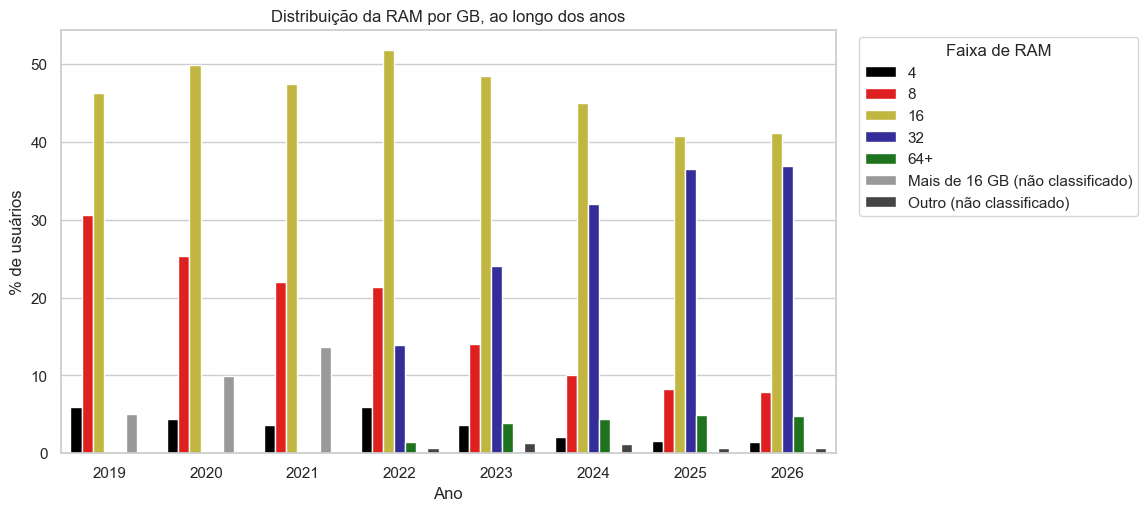

In [638]:
# Só a paleta de cores muda em relação ao padrão do seaborn
cores = {
    '4': '#000000',
    '8': '#FF0000',
    '16': "#d6c82a",
    '32': "#231cab",
    '64+': "#108110",
    'Mais de 16 GB (não classificado)': '#999999',
    'Outro (não classificado)': '#444444',
}

plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=df_memoria,
    x='Ano',
    y='Porcentagens',
    hue='Tier',
    hue_order=tiers_ordem,
    palette=cores
)

plt.title('Distribuição da RAM por GB, ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('% de usuários')
plt.legend(title='Faixa de RAM', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

#### RAM mês a mês (Set/2025 – Mai/2026)
Notebook original: `Análise dos dados/EDA_dados_mensais_unificados.ipynb` (segunda parte)

#### Análise de dados
Para a análise decidimos fazer cópias dos datasets limpos para cada análise já que cada análise precisará manipulações distintas dos dados.

In [117]:
df_memoria = df[df['Categoria'] == 'System RAM'].reset_index(drop=True)
chave = df_memoria["Ano"] * 12 + df_memoria["Mês"].map(ORDEM_MESES)
inicio = 2025 * 12 + ORDEM_MESES["Setembro"]
fim = chave.max()

df_memoria = df_memoria[(chave >= inicio) & (chave <= fim)].copy().reset_index(drop=True)
df_memoria.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
0,System RAM,Less than 4 GB,0.02,0.00,Setembro,2025
1,System RAM,4 GB,1.55,-0.03,Setembro,2025
2,System RAM,8 GB,8.05,-0.06,Setembro,2025
3,System RAM,12 GB,2.57,0.02,Setembro,2025
4,System RAM,16 GB,41.76,-0.12,Setembro,2025


In [118]:
df_memoria['Especificação'].unique()

<StringArray>
[ 'Less than 4 GB',            '4 GB',            '8 GB',           '12 GB',
           '16 GB',           '24 GB',           '28 GB',           '32 GB',
           '48 GB',           '60 GB',           '64 GB', 'More than 64 GB',
           'Other']
Length: 13, dtype: str

In [123]:
tiers_ordem = ['-4','4', '8','12','16','24','28','32','48','60','64', '64+', 'Outro (não classificado)']

# "Tabela de tradução": cada texto original vira uma faixa de RAM.
# Textos que não aparecem aqui (ex: '2 GB', 'Less than 2 GB') viram NaN.
mapa_tier = {
    'Less than 4 GB' : '-4',
    '4 GB': '4',
    '8 GB': '8',
    '12 GB' : '12',
    '16 GB': '16',
    '24 GB' : '24',
    '28 GB' : '28',
    '32 GB': '32',
    '48 GB' : '48',
    '60 GB' : '60', 
    '64 GB': '64',
    'More than 64 GB': '64+',
    'Other': 'Outro (não classificado)',
}

df_tiers = df_memoria[df_memoria['Categoria'] == 'System RAM'].copy()
df_tiers['Tier'] = df_tiers['Especificação'].map(mapa_tier)
df_tiers = df_tiers.dropna(subset=['Tier'])

# Agrupamento: soma a porcentagem de cada faixa de RAM, por ano
tier_pct = df_tiers.groupby(['Ano', 'Tier', 'Mês'])['Porcentagens'].sum().reset_index()
tier_pct.head()

,Ano,Tier,Mês,Porcentagens
0,2025,-4,Dezembro,0.02
1,2025,-4,Novembro,0.02
2,2025,-4,Outubro,0.02
3,2025,-4,Setembro,0.02
4,2025,12,Dezembro,2.63


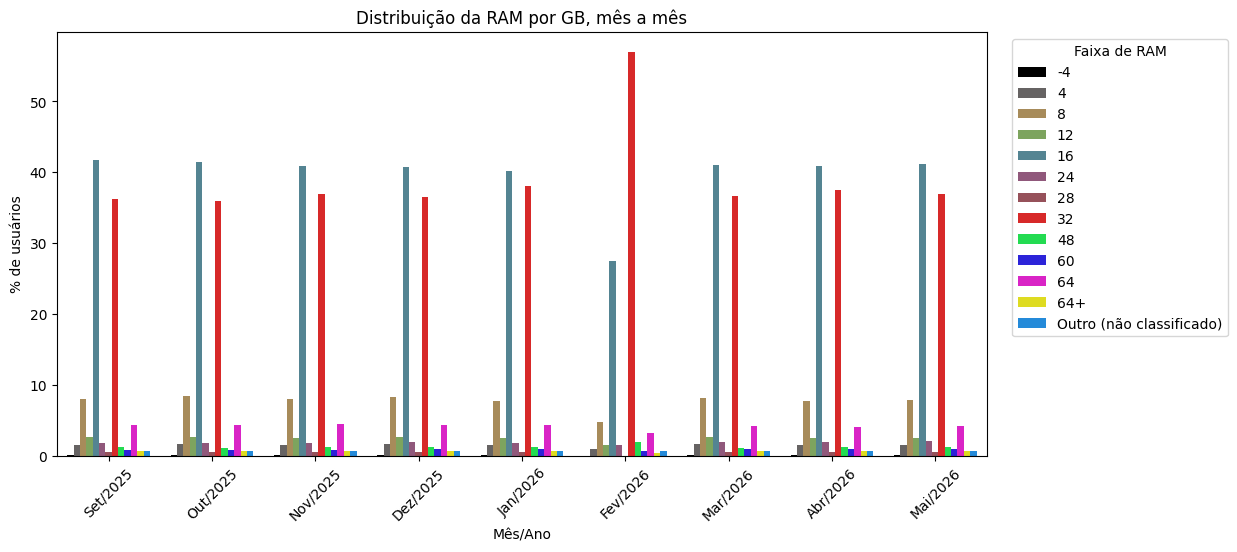

In [ ]:
tier_pct['Periodo'] = tier_pct['Mês'].str.slice(0, 3) + '/' + tier_pct['Ano'].astype(str)
ordem_periodo = (
    tier_pct[['Ano', 'Mês', 'Periodo']]
    .drop_duplicates()
    .assign(chave=lambda d: d['Ano'] * 12 + d['Mês'].map(ORDEM_MESES))
    .sort_values('chave')['Periodo']
    .tolist()
)

cores = {
    '-4' : '#000000',
        '4': "#666363",
        '8': "#B48E4D",
        '12' : "#7CB052",
        '16': "#4A8A9C",
        '24' : "#994F7D",
        '28' : "#A14652",
        '32': "#F40C0C",
        '48' : "#05F942",
        '60' : "#1105F7", 
        '64': "#F706DE",
        '64+':"#FEFA01",
        'Outro (não classificado)': "#068EF7",
}

plt.figure(figsize=(12, 5.5))

ax = sns.barplot(
    data=tier_pct,
    x='Periodo',
    order=ordem_periodo,
    y='Porcentagens',
    hue='Tier',
    hue_order=tiers_ordem,
    palette=cores
)

plt.title('Distribuição da RAM por GB, mês a mês')
plt.xlabel('Mês/Ano')
plt.ylabel('% de usuários')
plt.xticks(rotation=45)
plt.legend(title='Faixa de RAM', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

### Resultado da análise. 
É possível verificar uma constante transição para uma quantidade cada vez maior de memória RAM com a ascensão dos 32GB e a queda da popularidade dos 16GB de memória além das quantidades mais baixas como 8GB e 4GB em um grande declínio com o segundo quase sumindo do mercado. Além disso, é claro nos dados o impacto da crise de chips de memória que ocasionou uma estagnação dos dados desde que iniciou o que é possível interpretar que os usuários estão deixando de fazer upgrade pela alta nos preços.

#### Análise RAM com regressão linear

In [ ]:
df_ram = df_anual[df_anual['Categoria'] == 'System RAM']
df_ram = df_ram[(df_ram['Especificação'] == '4 GB') |
                ( df_ram['Especificação'] == '8 GB') |
                (df_ram['Especificação'] == '16 GB') |
                (df_ram['Especificação'] == '32 GB') |
                (df_ram['Especificação'] == '64 GB')]
df_ram

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
24,System RAM,4 GB,6.00,-5.05,2019
28,System RAM,8 GB,30.69,-7.21,2019
36,System RAM,16 GB,46.37,15.10,2019
201,System RAM,4 GB,4.39,-3.10,2020
205,System RAM,8 GB,25.32,-9.65,2020
213,System RAM,16 GB,49.95,11.68,2020
387,System RAM,4 GB,3.64,-1.25,2021
391,System RAM,8 GB,21.96,-6.65,2021
399,System RAM,16 GB,47.43,3.59,2021
586,System RAM,4 GB,5.89,-1.63,2022


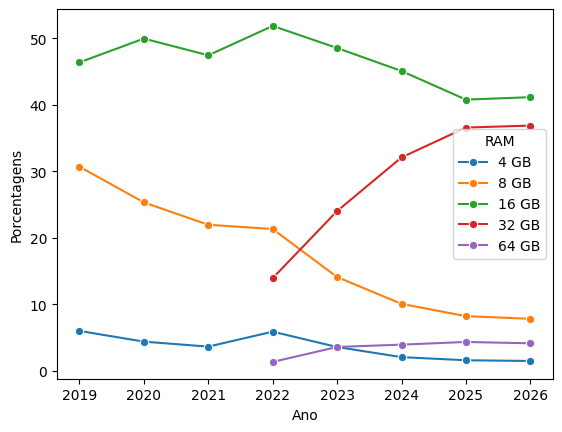

In [65]:
ax = sns.lineplot(data=df_ram, x='Ano', y='Porcentagens', hue='Especificação', marker='o')
ax.legend_.set_title(title="RAM")

In [66]:
df_ram_8 = df_ram[df_ram['Especificação'] == '8 GB']
df_ram_16 = df_ram[df_ram['Especificação'] == '16 GB']
df_ram_32 = df_ram[df_ram['Especificação'] == '32 GB']
df_ram_64 = df_ram[df_ram['Especificação'] == '64 GB']


In [67]:
result_8GB = linregress(df_ram_8['Ano'], df_ram_8['Porcentagens'])
result_16GB = linregress(df_ram_16['Ano'], df_ram_16['Porcentagens'])
result_32GB = linregress(df_ram_32['Ano'], df_ram_32['Porcentagens'])
result_64GB = linregress(df_ram_64['Ano'], df_ram_64['Porcentagens'])

In [68]:
def f8(x):
    if (result_8GB.slope * x + result_8GB.intercept <= 0):
        return 1.0
    else:
        return result_8GB.slope * x + result_8GB.intercept

def f16(x):
    if (result_16GB.slope * x + result_16GB.intercept <= 0):
        return 1.0
    else:
        return result_16GB.slope * x + result_16GB.intercept

def f32(x):
    if (result_32GB.slope * x + result_32GB.intercept <= 0):
        return 1.0
    else:
        return result_32GB.slope * x + result_32GB.intercept

def f64(x):
    if (result_64GB.slope * x + result_64GB.intercept <= 0):
        return 1.0
    else:
        return result_64GB.slope * x + result_64GB.intercept

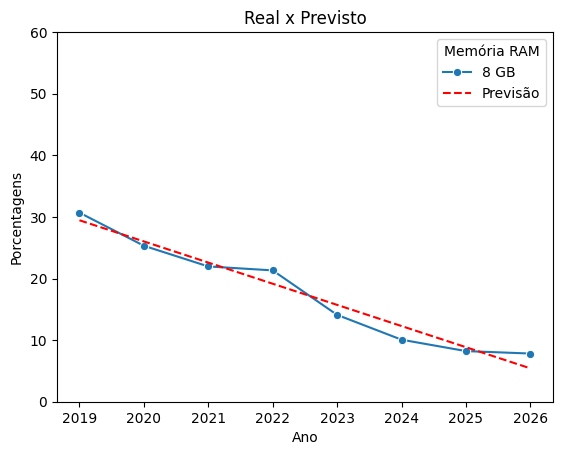

In [78]:
line = {'x': [2019, 2026], 'y': [f8(2019), f8(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_ram_8, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Memória RAM')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

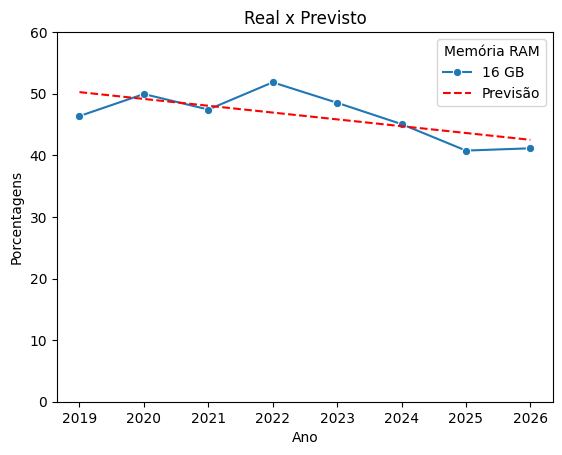

In [77]:
line = {'x': [2019, 2026], 'y': [f16(2019), f16(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_ram_16, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Memória RAM')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

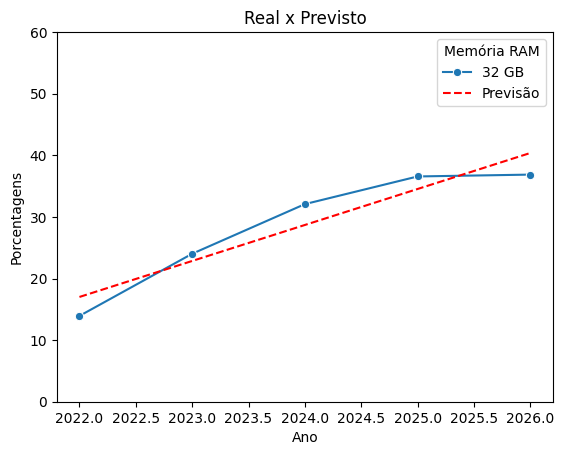

In [80]:
line = {'x': [2022, 2026], 'y': [f32(2022), f32(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_ram_32, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Memória RAM')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

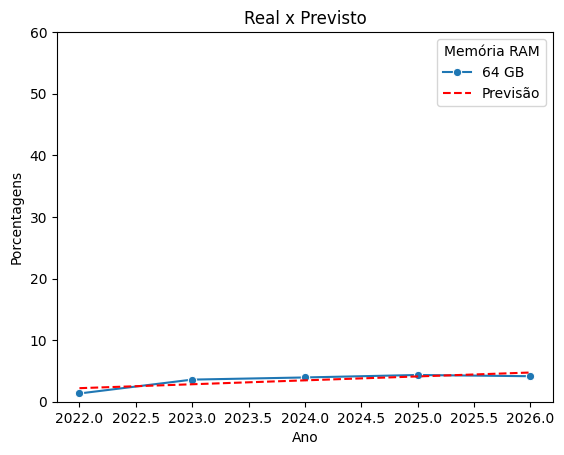

In [81]:
line = {'x': [2022, 2026], 'y': [f64(2022), f64(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_ram_64, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Memória RAM')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

In [73]:
dados = {
    'RAM' : ['8GB', '16GB', '32GB', '64GB'],
    'Porcentagem' : [f'{round(f8(2030), 2)}', f'{round(f16(2030), 2)}', f'{round(f32(2030), 2)}', f'{round(f64(2030), 2)}']
}

dados_ram = pd.DataFrame(dados)
dados_ram['Porcentagem'] = dados_ram['Porcentagem'].astype(float)
dados_ram

,RAM,Porcentagem
0,8GB,1.00
1,16GB,38.09
2,32GB,63.75
3,64GB,7.28


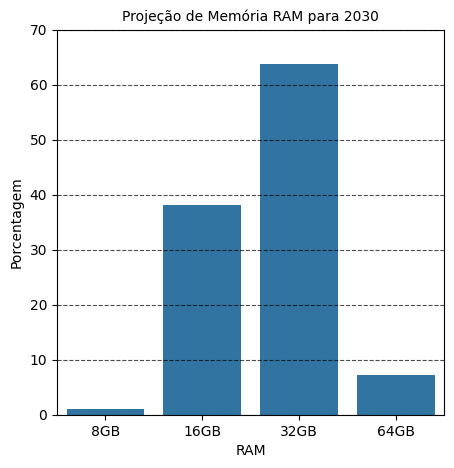

In [82]:
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=dados_ram, x='RAM', y='Porcentagem')
ax.invert_yaxis()
ax.set_ylim(0, 70)
ax.set_title('Projeção de Memória RAM para 2030', fontsize=10)
plt.grid(axis='y', color='black', linestyle='--', alpha=0.7)


#### RAM — projeção de 16 GB (regressão linear)
Notebook original: `Análise dos dados/Analise de Dados/analiseDados.ipynb`

-- Previs~oes Com Regressão Linear --
Ano 2026: 42.52 %
Ano 2027: 41.41 %
Ano 2028: 40.31 %
Ano 2029: 39.2 %
Ano 2030: 38.09 %


C:\Users\monte\AppData\Local\Temp\ipykernel_28168\3380718226.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Ano 2026:" , round(float(previsoes[0]),2) , "%")
C:\Users\monte\AppData\Local\Temp\ipykernel_28168\3380718226.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Ano 2027:" , round(float(previsoes[1]),2) , "%")
C:\Users\monte\AppData\Local\Temp\ipykernel_28168\3380718226.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Ano 2028

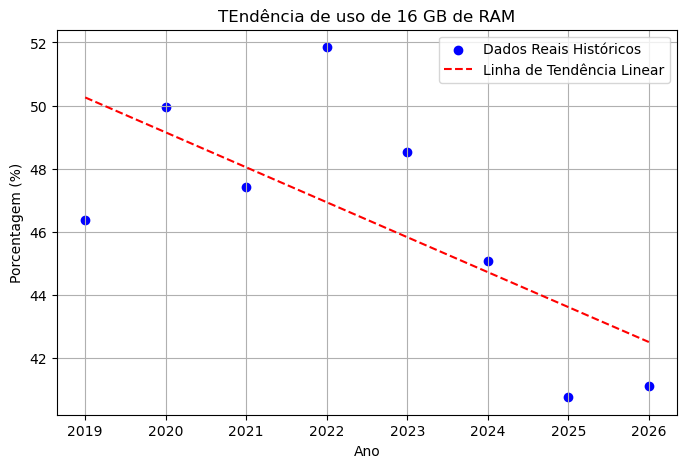

In [ ]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Análise dos dados/dados_anuais_novo.csv")
df_ram16 = df[(df["Categoria"] == "System RAM") & (df["Especificação"] == "16 GB")]

X = df_ram16[["Ano"]]
Y = df_ram16[["Porcentagens"]]

modelo = LinearRegression()
modelo.fit(X,Y)

anosFuturos = pd.DataFrame({"Ano": [2026, 2027, 2028, 2029, 2030]})
previsoes = modelo.predict(anosFuturos)
print("-- Previsões Com Regressão Linear --")
print("Ano 2026:" , round(float(previsoes[0]),2) , "%")
print("Ano 2027:" , round(float(previsoes[1]),2) , "%")
print("Ano 2028:" , round(float(previsoes[2]),2) , "%")
print("Ano 2029:" , round(float(previsoes[3]),2) , "%")
print("Ano 2030:" , round(float(previsoes[4]),2) , "%")

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color="blue", label="Dados Reais Históricos")
plt.plot(X, modelo.predict(X), color="red", linestyle="--", label="Linha de Tendência Linear")

plt.title("TEndência de uso de 16 GB de RAM")
plt.xlabel("Ano")
plt.ylabel("Porcentagem (%)")
plt.legend()
plt.grid(True)
plt.show()

### 2. VRAM
Distribuição anual por capacidade, perfis de hardware via K-Means e regressão linear com projeção até 2030.

Notebook original: `Análise dos dados/EDA_dados_anuais_unificados.ipynb`

##### Análise da evolução da quantidade de memória de vídeo utilizada pelos usuários da Steam

In [639]:
df_vram = df[df['Categoria'] == 'VRAM'].copy()

df_vram.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
151,VRAM,512 MB,1.37,-1.82,2019
152,VRAM,768 MB,0.52,-0.98,2019
153,VRAM,1024 MB,9.10,-6.84,2019
154,VRAM,2047 MB,15.53,-5.33,2019
155,VRAM,3071 MB,9.56,2.57,2019


In [640]:
df_vram['Especificação'].unique()

<StringArray>
[  '512 MB',   '768 MB',  '1024 MB',  '2047 MB',  '3071 MB',  '4095 MB',
  '5119 MB',  '6143 MB',  '8191 MB', '11263 MB',    'Other', '10239 MB',
 '12287 MB', '24575 MB',     '1 GB',     '2 GB',     '3 GB',     '4 GB',
     '5 GB',     '6 GB',     '8 GB',    '10 GB',    '11 GB',    '12 GB',
    '24 GB',    '16 GB',    '32 GB',    '20 GB',    '22 GB']
Length: 29, dtype: str

In [641]:
df_vram['Especificação'] = df_vram['Especificação'].str.replace("1024 MB","1 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("2047 MB","2 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("3071 MB","3 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("4095 MB","4 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("5119 MB","5 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("6143 MB","6 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("8191 MB","8 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("11263 MB","11 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("10239 MB","10 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("12287 MB","12 GB")
df_vram['Especificação'] = df_vram['Especificação'].str.replace("24575 MB","24 GB")

df_vram['Especificação'].unique()

<StringArray>
['512 MB', '768 MB',   '1 GB',   '2 GB',   '3 GB',   '4 GB',   '5 GB',
   '6 GB',   '8 GB',  '11 GB',  'Other',  '10 GB',  '12 GB',  '24 GB',
  '16 GB',  '32 GB',  '20 GB',  '22 GB']
Length: 18, dtype: str

In [642]:
tiers_ordem = ['0.5', '0.7', '1', '2', '3', '4', '5','6','8','10', '11', '12', '16','20','22','24','32', 'Outros']

mapa_tier = {
    '512 MB' : '0.5',
    '768 MB' : '0.7',
    '1 GB' : '1',
    '2 GB': '2',
    '3 GB' : '3',
    '4 GB' : '4',
    '5 GB' : '5',
    '6 GB' : '6',
    '8 GB' : '8',
    '10 GB': '10',
    '11 GB' : '11',
    '12 GB': '12',
    '24 GB' : '24',
    '16 GB' : '16',
    '20 GB' : '20',
    '22 GB': '22',
    '32 GB' : '32',
  'Other': 'Outros',
}

df_vram['Tier'] = df_vram['Especificação'].map(mapa_tier)
df_vram = df_vram.dropna(subset=['Tier'])

# Agrupamento: soma a porcentagem de cada faixa de RAM, por ano
df_vram = df_vram.groupby(['Ano', 'Tier'])['Porcentagens'].sum().reset_index()
df_vram.head()

,Ano,Tier,Porcentagens
0,2019,0.5,1.37
1,2019,0.7,0.52
2,2019,1,9.10
3,2019,11,2.52
4,2019,2,15.53


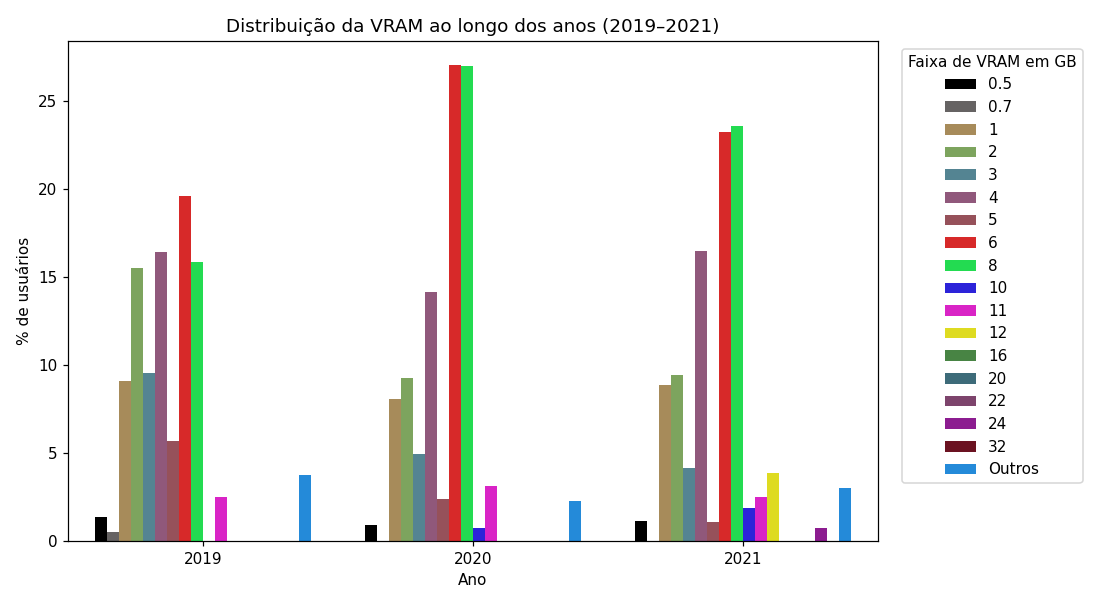

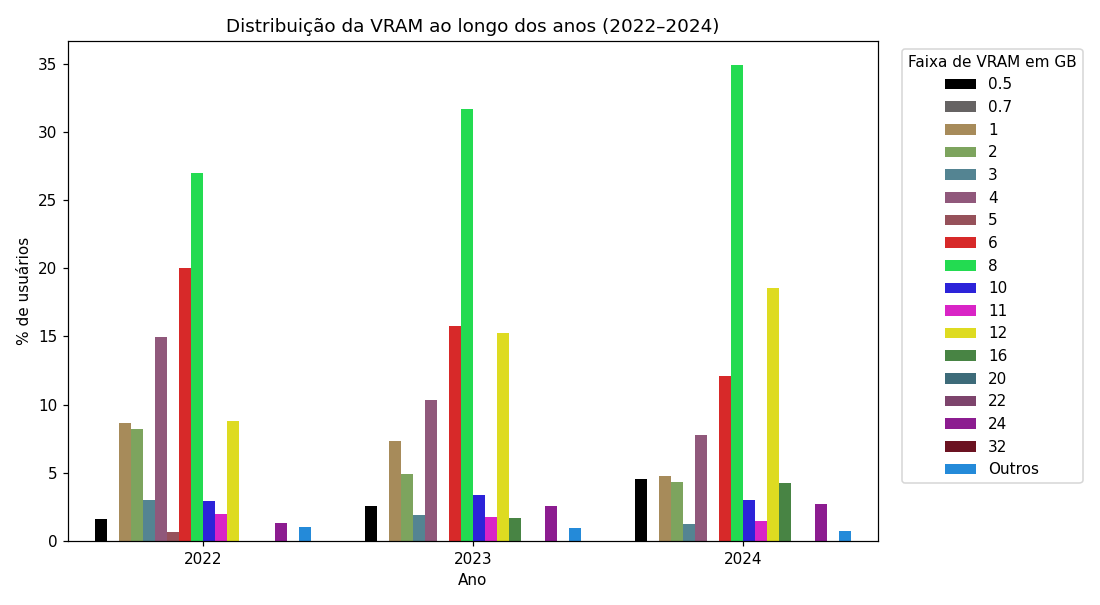

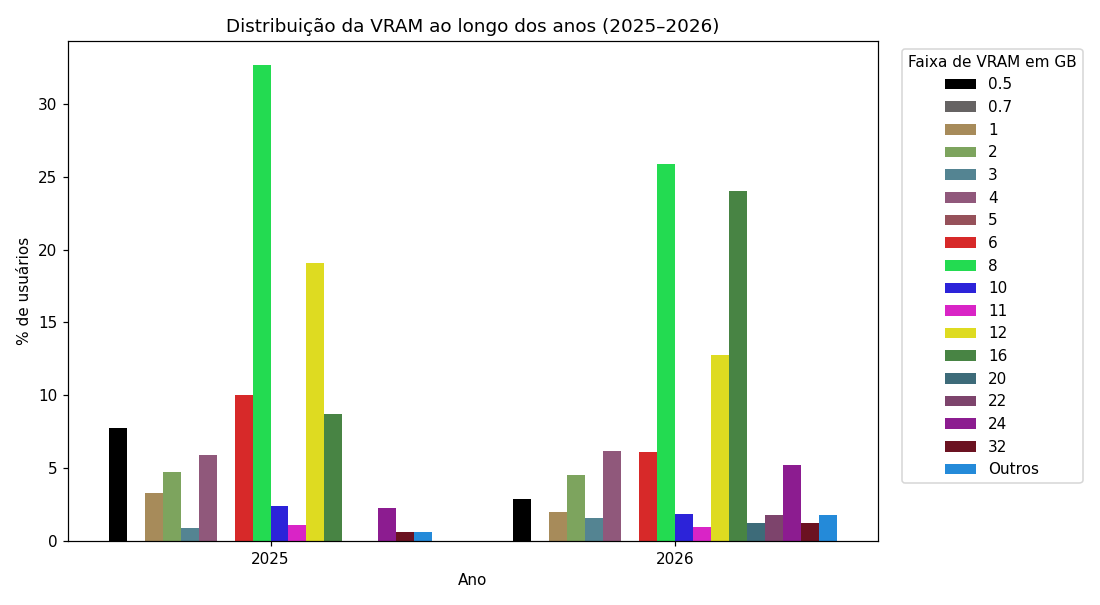

In [643]:

cores = {
    '0.5' : '#000000',
        '0.7': "#666363",
        '1': "#B48E4D",
        '2' : "#7CB052",
        '3': "#4A8A9C",
        '4' : "#994F7D",
        '5' : "#A14652",
        '6': "#F40C0C",
        '8' : "#05F942",
        '10' : "#1105F7", 
        '11': "#F706DE",
        '12':"#FEFA01",
        '16':"#3E8F39",
        '20':"#337183",
        '22':"#863A70",
        '24':"#9E09A3",
        '32':"#7A0317",
        'Outros': "#068EF7",
}

# Divide os anos em blocos de 3 em 3 para deixar cada gráfico de barras mais legível
anos_ordenados = sorted(df_vram['Ano'].unique())
blocos_anos = [anos_ordenados[i:i + 3] for i in range(0, len(anos_ordenados), 3)]

for bloco in blocos_anos:
    df_bloco = df_vram[df_vram['Ano'].isin(bloco)]

    plt.figure(figsize=(10, 5.5))

    ax = sns.barplot(
        data=df_bloco,
        x='Ano',
        y='Porcentagens',
        hue='Tier',
        hue_order=tiers_ordem,
        palette=cores
    )

    plt.title(f'Distribuição da VRAM ao longo dos anos ({bloco[0]}–{bloco[-1]})')
    plt.xlabel('Ano')
    plt.ylabel('% de usuários')
    plt.legend(title='Faixa de VRAM em GB', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.show()


### O QUE É POSSÍVEL INTERPRETAR DESSA ANÁLISE
•  A VRAM se fragmenta em muito mais faixas do que a RAM (18 tiers), refletindo a maior diversidade de modelos de GPU no mercado.
•  Faixas antigas (0,5–2 GB) praticamente desaparecem ao longo da série.
•  Faixas de 8–16 GB ganham espaço a partir de 2022–2023, coincidindo com a chegada das GPUs RTX 30/40.

##### Utilização do K-Means

In [644]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [645]:
df_vram = df_vram[df_vram['Tier'] != 'Outros']
df_vram['Tier'] = pd.to_numeric(df_vram['Tier'], errors='coerce')
df_vram = df_vram.dropna(subset=['Tier'])

In [646]:
df_perfis_historico = []


for ano in df_vram['Ano'].unique():
    # 1. Filtrar os dados do ano atual
    df_ano = df_vram[df_vram['Ano'] == ano].copy()
    
    scaler = StandardScaler()
    X_escalado = scaler.fit_transform(df_ano[['Tier', 'Porcentagens']])
    
    
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_ano['Cluster'] = kmeans.fit_predict(X_escalado)
    
    # O cluster com menor média de VRAM vira 'Entrada', o maior vira 'Entusiasta'
    ordem_vram = df_ano.groupby('Cluster')['Tier'].mean().sort_values().index
    mapeamento_perfis = {
        ordem_vram[0]: 'Entrada',
        ordem_vram[1]: 'Intermediário',
        ordem_vram[2]: 'Entusiasta'
    }
    df_ano['Perfil'] = df_ano['Cluster'].map(mapeamento_perfis)
    
    df_perfis_historico.append(df_ano)

# Junta todos os anos transformados de volta
df_final_clusterizado = pd.concat(df_perfis_historico)


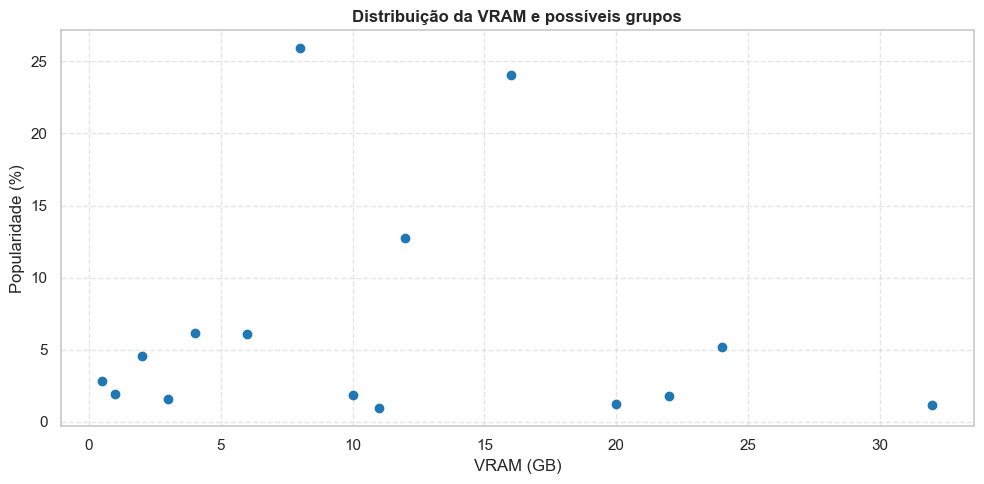

In [647]:
import matplotlib.pyplot as plt

df_simples = df_final_clusterizado[df_final_clusterizado['Ano'] == 2026]


plt.figure(figsize=(10, 5))


plt.scatter(
    df_simples['Tier'], 
    df_simples['Porcentagens'], 
    color='#1f77b4',
)


plt.title('Distribuição da VRAM e possíveis grupos', fontsize=12, fontweight='bold')
plt.xlabel('VRAM (GB)')
plt.ylabel('Popularidade (%)')
plt.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()


In [648]:
evolucao_vram = df_final_clusterizado.groupby(['Ano', 'Perfil'])['Tier'].mean().unstack()
print(evolucao_vram)


Perfil   Entrada  Entusiasta  Intermediário
Ano                                        
2019    2.040000       11.00       5.000000
2020    2.583333       10.50       7.000000
2021    2.300000       14.25       6.000000
2022    2.300000       14.25       6.000000
2023    2.100000       15.25       8.666667
2024    2.750000       15.25      10.000000
2025    5.944444       28.00      10.000000
2026    4.687500       24.50      12.000000


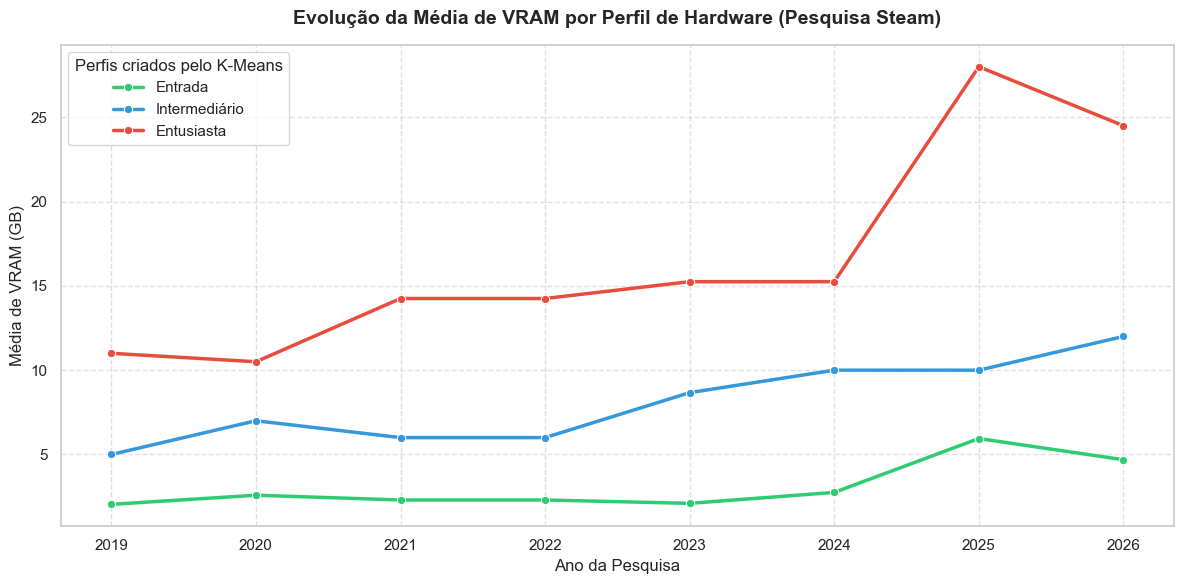

In [649]:
evolucao_vram.index = evolucao_vram.index.astype(int)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

cores = {
    'Entrada': '#2ecc71',       
    'Intermediário': '#3498db', 
    'Entusiasta': '#e74c3c'     
}

for perfil in ['Entrada', 'Intermediário', 'Entusiasta']:
    sns.lineplot(
        x=evolucao_vram.index,      
        y=evolucao_vram[perfil], 
        marker='o', 
        linewidth=2.5,
        label=perfil,
        color=cores[perfil]
    )

plt.title('Evolução da Média de VRAM por Perfil de Hardware (Pesquisa Steam)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano da Pesquisa', fontsize=12)
plt.ylabel('Média de VRAM (GB)', fontsize=12)
plt.xticks(evolucao_vram.index) 
plt.legend(title='Perfis criados pelo K-Means', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


#### Regressão Linear Simples

In [650]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [651]:
df_previsao = df_final_clusterizado.copy()

# Último ano com dados reais: a previsão começa a partir dele
ano_final = df_previsao['Ano'].max()

top_4_tiers = (
    df_previsao[df_previsao['Ano'] == ano_final]
    .sort_values('Porcentagens', ascending=False)
    .head(4)['Tier']
    .tolist()
)

In [ ]:
# Definindo os anos que vamos usar para prever o futuro
anos_futuros = list(range(ano_final + 1, 2031))  # previsão até 2030
todos_anos = sorted(df_previsao['Ano'].unique().tolist() + anos_futuros)

previsoes_tiers = {}

# Para cada um dos 4 Tiers selecionados, treinamos um modelo separado
for tier, grupo in df_previsao.groupby('Tier'):
    if tier not in top_4_tiers:
        continue

    X = grupo[['Ano']]
    Y = grupo['Porcentagens']

    modelo = LinearRegression()
    modelo.fit(X, Y)

    previsoes = modelo.predict(pd.DataFrame({'Ano': todos_anos}))
    previsoes = np.clip(previsoes, 0, None)  # porcentagem não pode ficar negativa
    previsoes_tiers[tier] = previsoes

    print(f"-- Previsões para {tier} GB --")
    for ano in anos_futuros:
        indice = todos_anos.index(ano)
        print(f"Ano {ano}:", round(float(previsoes[indice]), 2), "%")

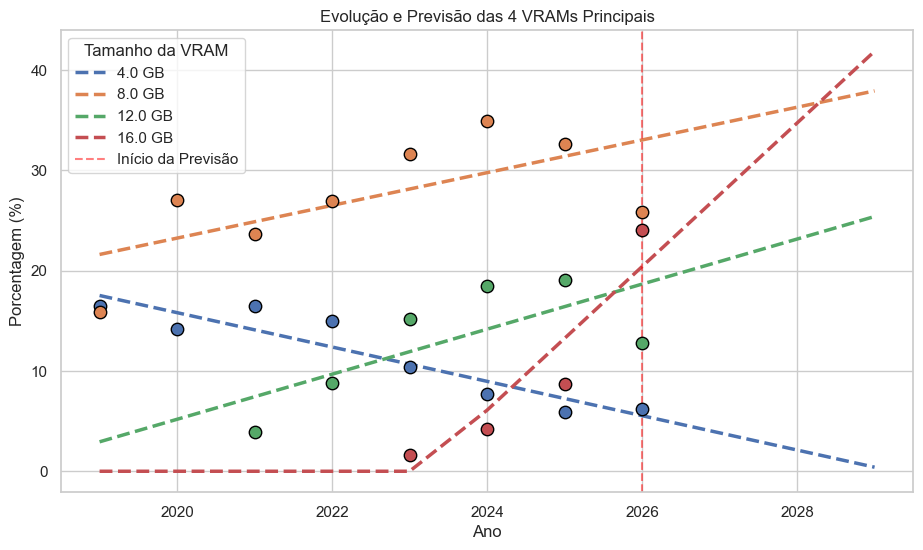

In [ ]:
plt.figure(figsize=(11, 6))

for tier, grupo in df_previsao.groupby('Tier'):
    if tier not in top_4_tiers:
        continue

    linha = plt.plot(todos_anos, previsoes_tiers[tier], linestyle='--', label=f'{tier} GB', linewidth=2.5)
    plt.scatter(grupo['Ano'], grupo['Porcentagens'], color=linha[0].get_color(), edgecolor='black', s=80, zorder=5)

plt.axvline(x=ano_final, color='red', linestyle='--', alpha=0.5, label='Início da Previsão')
plt.title('Evolução e Previsão das 4 VRAMs Principais')
plt.xlabel('Ano')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Tamanho da VRAM')
plt.grid(True)
plt.show()

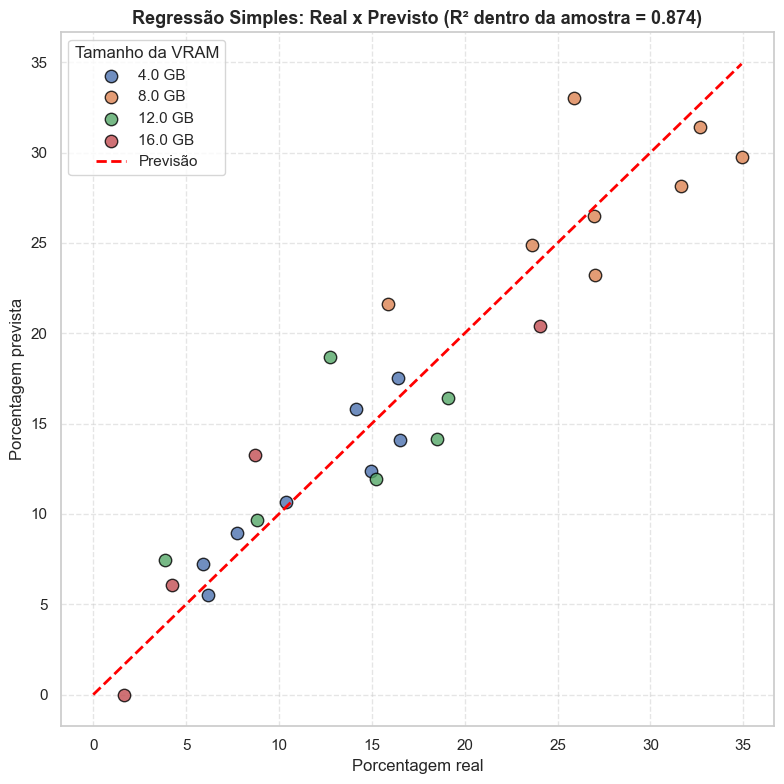

In [ ]:

plt.figure(figsize=(8, 8))

todos_valores_reais = []
todos_valores_previstos = []

for tier, grupo in df_previsao.groupby('Tier'):
    if tier not in top_4_tiers:
        continue

    mapa_previsao = dict(zip(todos_anos, previsoes_tiers[tier]))

    valores_reais = grupo['Porcentagens'].tolist()
    valores_previstos = [mapa_previsao[ano] for ano in grupo['Ano']]

    plt.scatter(valores_reais, valores_previstos, label=f'{tier} GB', edgecolor='black', alpha=0.8, s=80)

    todos_valores_reais.extend(valores_reais)
    todos_valores_previstos.extend(valores_previstos)


limite_min = min(todos_valores_reais + todos_valores_previstos)
limite_max = max(todos_valores_reais + todos_valores_previstos)
plt.plot([limite_min, limite_max], [limite_min, limite_max], color='red', linestyle='--', linewidth=2, label='Previsão')

r2_simples = r2_score(todos_valores_reais, todos_valores_previstos)
plt.title(f'Regressão Simples: Real x Previsto (R² dentro da amostra = {r2_simples:.3f})', fontsize=13, fontweight='bold')
plt.xlabel('Porcentagem real')
plt.ylabel('Porcentagem prevista')
plt.legend(title='Tamanho da VRAM')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Resultado da análise de VRAM por regressão linear
•  Entre os tiers mais populares em 2026 (8, 16, 12 e 4 GB), a regressão prevê os 16 GB ultrapassando os 8 GB por volta de 2028, chegando a ~49% em 2030.
•  O ajuste do modelo aos dados históricos tem R² = 0,87 dentro da amostra — um bom ajuste para uma regressão simples.
•  A faixa de 4 GB caminha para 0% já em 2029–2030.

### 3. CPU
Distribuição anual por número de núcleos físicos, regressão linear com projeção até 2030, e detalhe mês a mês para anos selecionados.

Notebook original: `Análise dos dados/Analise_Thiago.ipynb`

#### Análise das CPUs

In [15]:
df_cpus = df_anual[df_anual['Categoria'] == 'Physical CPUs']
df_cpus = df_cpus[( df_cpus['Especificação'] == '4 cpus') | 
                  (df_cpus['Especificação'] == '6 cpus') | 
                  (df_cpus['Especificação'] == '8 cpus') | 
                  (df_cpus['Especificação'] == '10 cpus') | 
                  (df_cpus['Especificação'] == '12 cpus') | 
                  (df_cpus['Especificação'] == '14 cpus') | 
                  (df_cpus['Especificação'] == '16 cpus')]
df_cpus.head(8)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
41,Physical CPUs,4 cpus,54.58,-1.43,2019
43,Physical CPUs,6 cpus,21.26,11.24,2019
45,Physical CPUs,8 cpus,4.40,2.61,2019
46,Physical CPUs,10 cpus,0.06,0.00,2019
48,Physical CPUs,12 cpus,0.14,0.10,2019
49,Physical CPUs,14 cpus,0.01,0.00,2019
51,Physical CPUs,16 cpus,0.05,0.01,2019
218,Physical CPUs,4 cpus,39.55,-10.80,2020


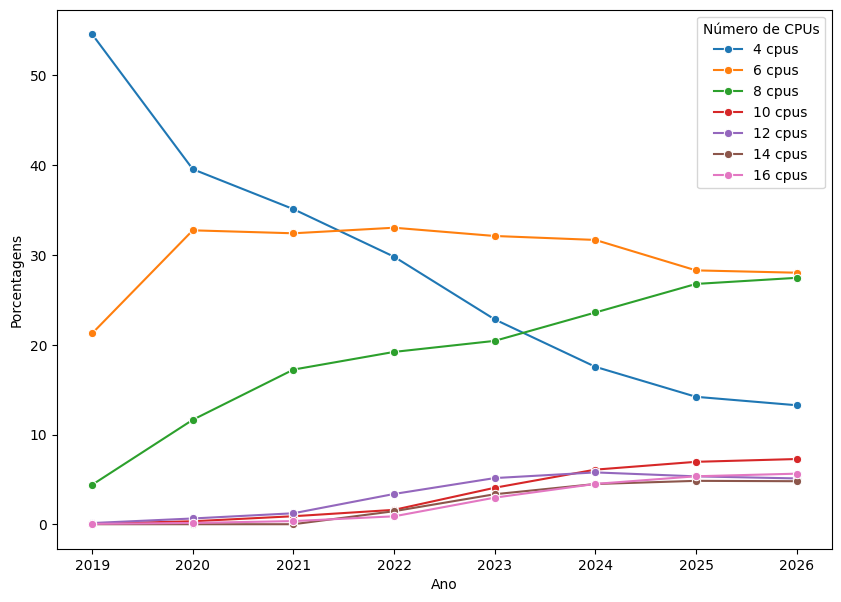

In [16]:
plt.figure(figsize=(10, 7))
ax = sns.lineplot(data=df_cpus, x='Ano', y='Porcentagens', hue='Especificação', marker='o')
ax.legend_.set_title(title="Número de CPUs")

In [17]:
df_cpus_4 = df_cpus[df_cpus['Especificação'] == '4 cpus']
df_cpus_6 = df_cpus[df_cpus['Especificação'] == '6 cpus']
df_cpus_8 = df_cpus[df_cpus['Especificação'] == '8 cpus']
df_cpus_10 = df_cpus[df_cpus['Especificação'] == '10 cpus']
df_cpus_12 = df_cpus[df_cpus['Especificação'] == '12 cpus']
df_cpus_14 = df_cpus[df_cpus['Especificação'] == '14 cpus']
df_cpus_16 = df_cpus[df_cpus['Especificação'] == '16 cpus']

In [18]:
result_4cpus = linregress(df_cpus_4['Ano'], df_cpus_4['Porcentagens'])
result_6cpus = linregress(df_cpus_6['Ano'], df_cpus_6['Porcentagens'])
result_8cpus = linregress(df_cpus_8['Ano'], df_cpus_8['Porcentagens'])
result_10cpus = linregress(df_cpus_10['Ano'], df_cpus_10['Porcentagens'])
result_12cpus = linregress(df_cpus_12['Ano'], df_cpus_12['Porcentagens'])
result_14cpus = linregress(df_cpus_14['Ano'], df_cpus_14['Porcentagens'])
result_16cpus = linregress(df_cpus_16['Ano'], df_cpus_16['Porcentagens'])

In [19]:
def f4_cpus(x):
    if (result_4cpus.slope * x + result_4cpus.intercept <= 0):
        return 1.0
    else:
        return result_4cpus.slope * x + result_4cpus.intercept
    
def f6_cpus(x):
    if (result_6cpus.slope * x + result_6cpus.intercept <= 0):
        return 1.0
    else:
        return result_6cpus.slope * x + result_6cpus.intercept

def f8_cpus(x):
    if (result_8cpus.slope * x + result_8cpus.intercept <= 0):
        return 1.0
    else:
        return result_8cpus.slope * x + result_8cpus.intercept

def f10_cpus(x):
    if (result_10cpus.slope * x + result_10cpus.intercept <= 0):
        return 1.0
    else:
        return result_10cpus.slope * x + result_10cpus.intercept

def f12_cpus(x):
    if (result_12cpus.slope * x + result_12cpus.intercept <= 0):
        return 1.0
    else:
        return result_12cpus.slope * x + result_12cpus.intercept

def f14_cpus(x):
    if (result_14cpus.slope * x + result_14cpus.intercept <= 0):
        return 1.0
    else:
        return result_14cpus.slope * x + result_14cpus.intercept

def f16_cpus(x):
    if (result_16cpus.slope * x + result_16cpus.intercept <= 0):
        return 1.0
    else:
        return result_16cpus.slope * x + result_16cpus.intercept

In [20]:
dados = {
    'CPUs' : ['4', '6', '8', '10', '12', '14', '16'],
    'Porcentagem' : [f'{round(f4_cpus(2030), 2)}',
                    f'{round(f6_cpus(2030), 2)}',
                    f'{round(f8_cpus(2030), 2)}',
                    f'{round(f10_cpus(2030), 2)}', 
                    f'{round(f12_cpus(2030), 2)}', 
                    f'{round(f14_cpus(2030), 2)}', 
                    f'{round(f16_cpus(2030), 2)}', ]
}

dados_cpus = pd.DataFrame(dados)
dados_cpus['Porcentagem'] = dados_cpus['Porcentagem'].astype(float)
dados_cpus

,CPUs,Porcentagem
0,4,1.00
1,6,31.89
2,8,41.81
3,10,12.48
4,12,9.92
5,14,8.89
6,16,9.60


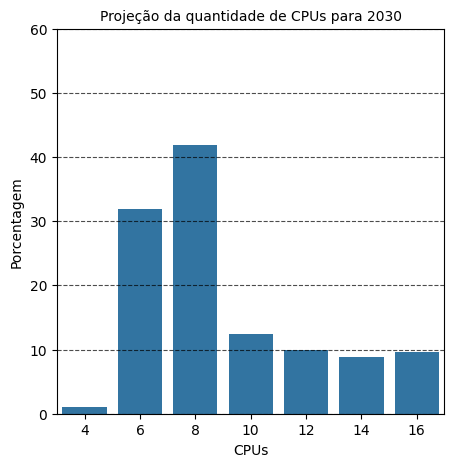

In [83]:
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=dados_cpus, x='CPUs', y='Porcentagem')
ax.invert_yaxis()
ax.set_ylim(0, 60)
ax.set_title('Projeção da quantidade de CPUs para 2030', fontsize=10)
plt.grid(axis='y', color='black', linestyle='--', alpha=0.7)

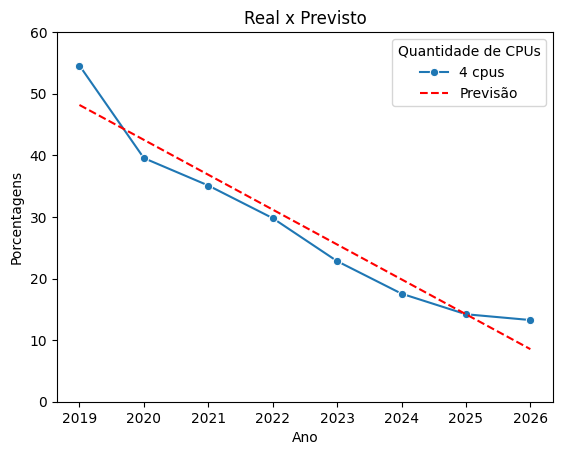

In [87]:
line = {'x': [2019, 2026], 'y': [f4_cpus(2019), f4_cpus(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_cpus_4, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Quantidade de CPUs')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

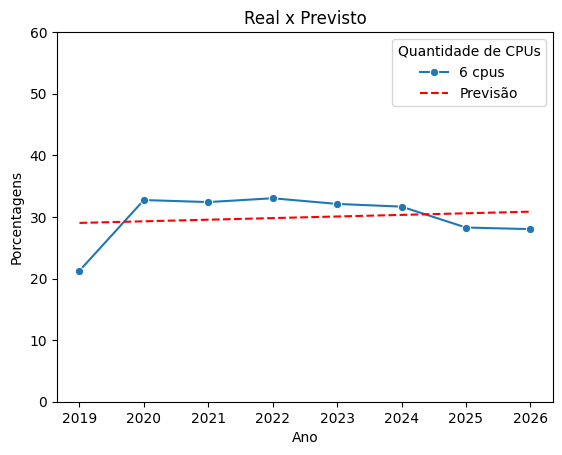

In [89]:
line = {'x': [2019, 2026], 'y': [f6_cpus(2019), f6_cpus(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_cpus_6, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Quantidade de CPUs')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

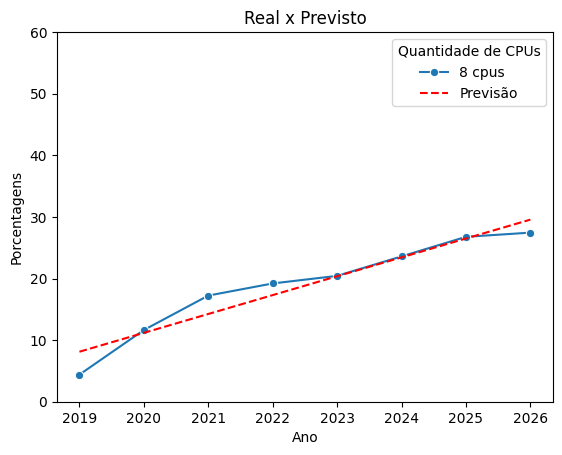

In [88]:
line = {'x': [2019, 2026], 'y': [f8_cpus(2019), f8_cpus(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_cpus_8, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Quantidade de CPUs')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

#### CPUs físicas mês a mês (2020, 2021 e 2023)

In [36]:
cpus2020 = df_mensal[(df_mensal['Categoria'] == 'Physical CPUs') & (df_mensal['Ano'] == 2020)]
cpus2020['Especificação'] = cpus2020['Especificação'].str.replace(r'(\d+)+.*$', r'\1', regex=True).str.strip()
cpus2020["Especificação"] = pd.to_numeric(cpus2020["Especificação"], errors="coerce")
cpus2020['Especificação'] = cpus2020['Especificação'].fillna(0).astype(int)
cpus2020 = cpus2020[(cpus2020['Especificação'] <= 8) & (cpus2020['Especificação'] > 0) & ((cpus2020['Especificação'] % 2) == 0)]
cpus2020.head(15)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
2311,Physical CPUs,2,21.57,0.17,Janeiro,2020
2313,Physical CPUs,4,50.35,-1.56,Janeiro,2020
2315,Physical CPUs,6,20.06,0.42,Janeiro,2020
2317,Physical CPUs,8,5.71,0.93,Janeiro,2020
2505,Physical CPUs,2,22.03,0.46,Fevereiro,2020
2507,Physical CPUs,4,49.22,-1.13,Fevereiro,2020
2509,Physical CPUs,6,20.65,0.59,Fevereiro,2020
2511,Physical CPUs,8,5.84,0.13,Fevereiro,2020
2706,Physical CPUs,2,20.68,-1.35,Março,2020
2708,Physical CPUs,4,48.03,-1.19,Março,2020


In [37]:
cpus2021 = df_mensal[(df_mensal['Categoria'] == 'Physical CPUs') & (df_mensal['Ano'] == 2021)]
cpus2021['Especificação'] = cpus2021['Especificação'].str.replace(r'(\d+)+.*$', r'\1', regex=True).str.strip()
cpus2021["Especificação"] = pd.to_numeric(cpus2021["Especificação"], errors="coerce")
cpus2021['Especificação'] = cpus2021['Especificação'].fillna(0).astype(int)
cpus2021 = cpus2021[(cpus2021['Especificação'] <= 8) & (cpus2021['Especificação'] > 0) & ((cpus2021['Especificação'] % 2) == 0)]
cpus2021.head(15)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
4636,Physical CPUs,2,15.66,1.41,Janeiro,2021
4638,Physical CPUs,4,42.94,2.75,Janeiro,2021
4640,Physical CPUs,6,27.87,-3.89,Janeiro,2021
4642,Physical CPUs,8,11.04,-0.47,Janeiro,2021
4828,Physical CPUs,2,14.74,-0.92,Fevereiro,2021
4830,Physical CPUs,4,41.95,-0.99,Fevereiro,2021
4832,Physical CPUs,6,28.76,0.89,Fevereiro,2021
4834,Physical CPUs,8,11.95,0.91,Fevereiro,2021
5018,Physical CPUs,2,14.33,-0.41,Março,2021
5020,Physical CPUs,4,41.40,-0.55,Março,2021


In [42]:
cpus2023 = df_mensal[(df_mensal['Categoria'] == 'Physical CPUs') & (df_mensal['Ano'] == 2023)]
cpus2023['Especificação'] = cpus2023['Especificação'].str.replace(r'(\d+)+.*$', r'\1', regex=True).str.strip()
cpus2023["Especificação"] = pd.to_numeric(cpus2023["Especificação"], errors="coerce")
cpus2023['Especificação'] = cpus2023['Especificação'].fillna(0).astype(int)
cpus2023 = cpus2023[(cpus2023['Especificação'] <= 8) & (cpus2023['Especificação'] > 0) & ((cpus2023['Especificação'] % 2) == 0)]
cpus2023.head(15)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
9232,Physical CPUs,2,9.95,0.06,Janeiro,2023
9234,Physical CPUs,4,29.51,-0.29,Janeiro,2023
9236,Physical CPUs,6,32.08,-0.95,Janeiro,2023
9238,Physical CPUs,8,19.55,0.35,Janeiro,2023
9430,Physical CPUs,2,9.00,-0.95,Fevereiro,2023
9432,Physical CPUs,4,27.96,-1.55,Fevereiro,2023
9434,Physical CPUs,6,33.42,1.34,Fevereiro,2023
9436,Physical CPUs,8,20.09,0.54,Fevereiro,2023
9616,Physical CPUs,2,5.41,-3.59,Março,2023
9618,Physical CPUs,4,20.94,-7.02,Março,2023


(0.0, 60.0)

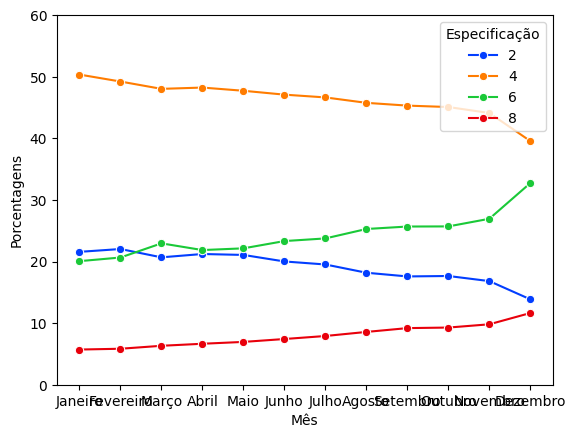

In [39]:
sns.lineplot(data=cpus2020, x='Mês', y='Porcentagens', hue='Especificação', palette='bright', marker='o')
plt.ylim((0, 60))

(0.0, 60.0)

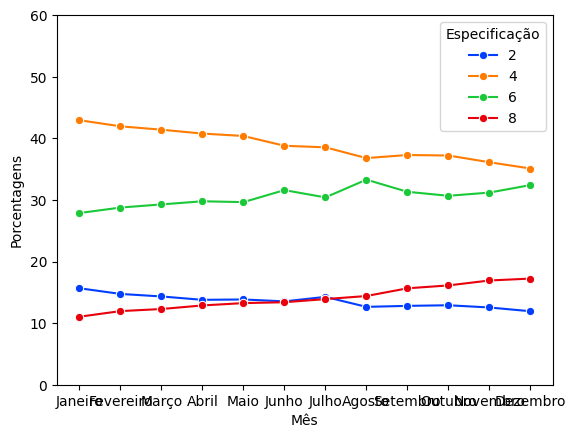

In [40]:
sns.lineplot(data=cpus2021, x='Mês', y='Porcentagens', hue='Especificação', palette='bright', marker='o')
plt.ylim((0, 60))

(0.0, 60.0)

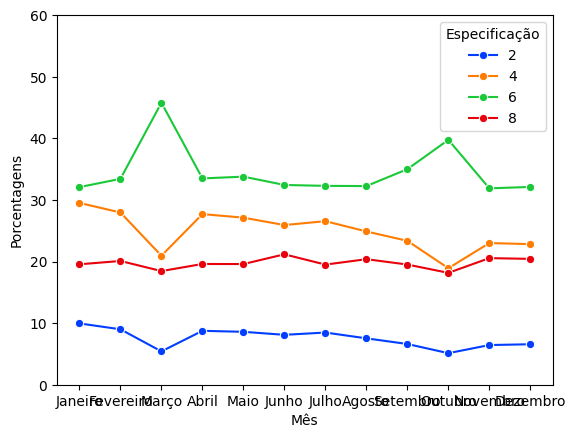

In [43]:
sns.lineplot(data=cpus2023, x='Mês', y='Porcentagens', hue='Especificação', palette='bright', marker='o')
plt.ylim((0, 60))

### 4. GPU (Placa de Vídeo)
Distribuição de mercado por fabricante (NVIDIA, AMD, Intel).

Notebook original: `Análise dos dados/Analise_Thiago.ipynb`

In [31]:
df_video = df_anual[df_anual['Categoria'] == 'Video Card Description']
df_video

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
59,Video Card Description,NVIDIA GeForce GTX 1060,20.30,5.99,2019
60,Video Card Description,NVIDIA GeForce GTX 1050 Ti,9.23,0.24,2019
61,Video Card Description,NVIDIA GeForce GTX 1050,4.50,-0.49,2019
62,Video Card Description,NVIDIA GeForce GTX 1070,3.82,-0.37,2019
63,Video Card Description,NVIDIA GeForce GTX 960,3.70,0.33,2019
...,...,...,...,...,...
1564,Video Card Description,AMD Radeon Graphics,1.92,0.07,2026
1565,Video Card Description,Intel(R) Graphics,0.37,0.09,2026
1566,Video Card Description,AMD Radeon RX 5700 XT,0.57,0.00,2026
1567,Video Card Description,NVIDIA GeForce RTX 4060,3.55,-0.61,2026


In [32]:
df_video['Especificação'] = df_video['Especificação'].str.replace(r'(NVIDIA).*$', r'\1', regex=True).str.replace(r'(AMD).*$', r'\1', regex=True).str.replace(r'(Intel).*$', r'\1', regex=True).str.strip()
df_video

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
59,Video Card Description,NVIDIA,20.30,5.99,2019
60,Video Card Description,NVIDIA,9.23,0.24,2019
61,Video Card Description,NVIDIA,4.50,-0.49,2019
62,Video Card Description,NVIDIA,3.82,-0.37,2019
63,Video Card Description,NVIDIA,3.70,0.33,2019
...,...,...,...,...,...
1564,Video Card Description,AMD,1.92,0.07,2026
1565,Video Card Description,Intel,0.37,0.09,2026
1566,Video Card Description,AMD,0.57,0.00,2026
1567,Video Card Description,NVIDIA,3.55,-0.61,2026


In [33]:
df_video = df_video[(df_video['Especificação'] == 'NVIDIA') | (df_video['Especificação'] == 'AMD') |(df_video['Especificação'] == 'Intel')]
df_video

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
59,Video Card Description,NVIDIA,20.30,5.99,2019
60,Video Card Description,NVIDIA,9.23,0.24,2019
61,Video Card Description,NVIDIA,4.50,-0.49,2019
62,Video Card Description,NVIDIA,3.82,-0.37,2019
63,Video Card Description,NVIDIA,3.70,0.33,2019
...,...,...,...,...,...
1563,Video Card Description,AMD,0.34,0.02,2026
1564,Video Card Description,AMD,1.92,0.07,2026
1565,Video Card Description,Intel,0.37,0.09,2026
1566,Video Card Description,AMD,0.57,0.00,2026


In [34]:
distribuicao_video = df_video.groupby(['Especificação', 'Ano'])['Porcentagens'].sum().reset_index()
distribuicao_video

,Especificação,Ano,Porcentagens
0,AMD,2019,7.66
1,AMD,2020,9.99
2,AMD,2021,10.57
3,AMD,2022,10.62
4,AMD,2023,12.17
5,AMD,2024,16.44
6,AMD,2025,14.63
7,AMD,2026,14.40
8,Intel,2019,7.38
9,Intel,2020,7.12


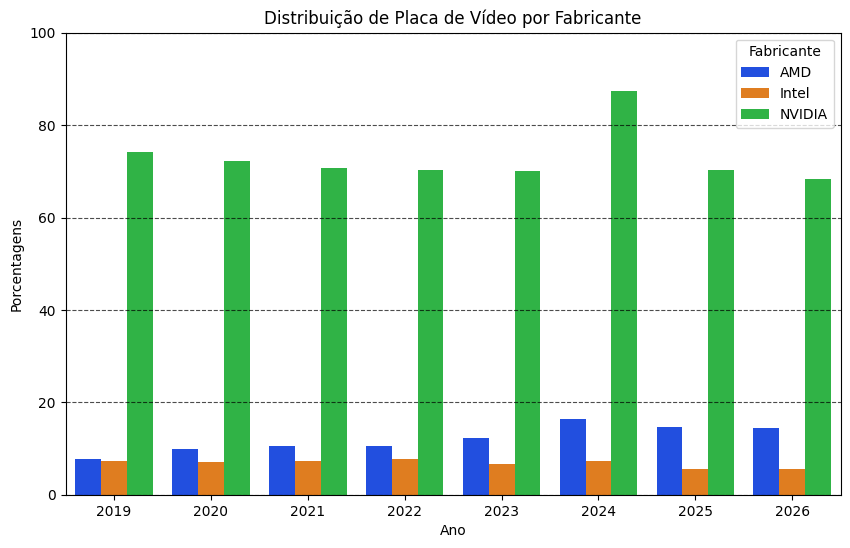

In [35]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=distribuicao_video, x='Ano', y='Porcentagens', hue='Especificação', palette='bright')
ax.legend_.set_title('Fabricante')
ax.set_title('Distribuição de Placa de Vídeo por Fabricante')
plt.ylim((0,100))
plt.grid(axis='y', color='black', linestyle='--', alpha=0.7)

### 5. Sistema Operacional
Comparação entre versões do Windows mês a mês, evolução anual de OSX/Linux, e correlação entre versões do Windows.

Notebook original: `Análise dos dados/Analise_Thiago.ipynb` e `Análise dos dados/Analise de Dados/analiseDados.ipynb`

In [51]:
df_windows2026 = df_mensal[(df_mensal['Especificação'] == 'Windows 11 64 bit') | (df_mensal['Especificação'] == 'Windows 10 64 bit') ]
df_windows2026 = df_windows2026[df_windows2026['Ano'] == 2026]
df_windows2026

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
16276,OS Version,Windows 11 64 bit,66.71,0.11,Janeiro,2026
16277,OS Version,Windows 10 64 bit,27.79,0.28,Janeiro,2026
16492,OS Version,Windows 11 64 bit,56.28,-10.43,Fevereiro,2026
16493,OS Version,Windows 10 64 bit,40.25,12.46,Fevereiro,2026
16676,OS Version,Windows 11 64 bit,66.85,10.57,Março,2026
16677,OS Version,Windows 10 64 bit,25.36,-14.89,Março,2026
16890,OS Version,Windows 11 64 bit,67.74,0.89,Abril,2026
16891,OS Version,Windows 10 64 bit,25.63,0.27,Abril,2026
17109,OS Version,Windows 11 64 bit,69.76,2.02,Maio,2026
17110,OS Version,Windows 10 64 bit,23.99,-1.64,Maio,2026


In [52]:
df_windows2025 = df_mensal[(df_mensal['Especificação'] == 'Windows 11 64 bit') | (df_mensal['Especificação'] == 'Windows 10 64 bit') ]
df_windows2025 = df_windows2025[df_windows2025['Ano'] == 2025]
df_windows2025

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
13827,OS Version,Windows 11 64 bit,53.46,0.34,Janeiro,2025
13828,OS Version,Windows 10 64 bit,42.87,0.13,Janeiro,2025
14021,OS Version,Windows 10 64 bit,53.34,10.47,Fevereiro,2025
14022,OS Version,Windows 11 64 bit,44.10,-9.36,Fevereiro,2025
14203,OS Version,Windows 11 64 bit,55.34,11.24,Março,2025
14204,OS Version,Windows 10 64 bit,40.58,-12.76,Março,2025
14403,OS Version,Windows 11 64 bit,57.84,2.50,Abril,2025
14404,OS Version,Windows 10 64 bit,38.09,-2.49,Abril,2025
14604,OS Version,Windows 11 64 bit,58.30,0.46,Maio,2025
14605,OS Version,Windows 10 64 bit,37.00,-1.09,Maio,2025


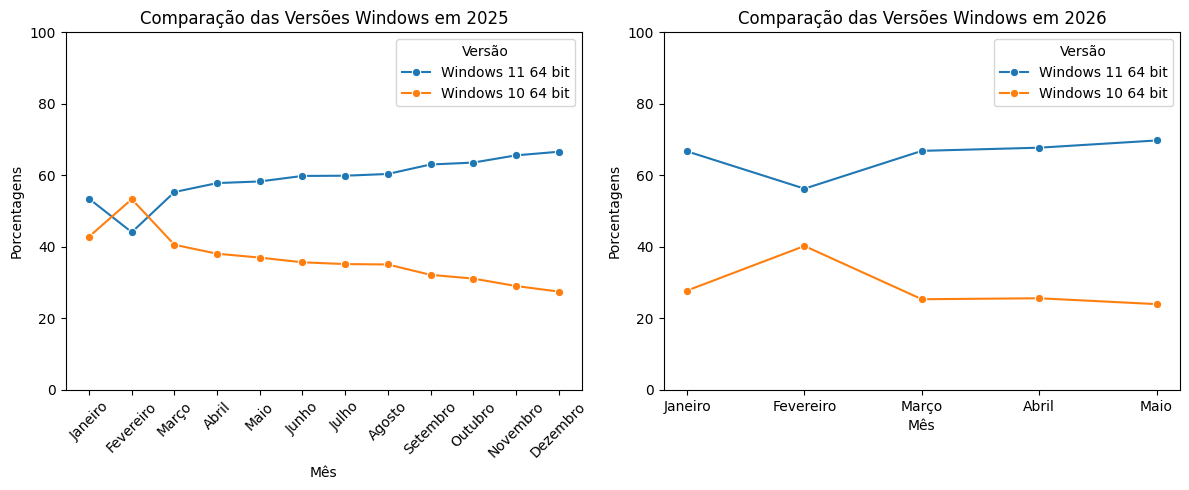

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(data=df_windows2025, x='Mês', y='Porcentagens', hue='Especificação', marker='o', ax=axes[0])
axes[0].set_title('Comparação das Versões Windows em 2025')
axes[0].legend_.set_title('Versão')
axes[0].set_ylim((0,100))
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=df_windows2026, x='Mês', y='Porcentagens', hue='Especificação', marker='o', ax=axes[1])
axes[1].set_title('Comparação das Versões Windows em 2026')
axes[1].legend_.set_title('Versão')
axes[1].set_ylim((0,100))
plt.ylim((0, 100))
plt.tight_layout()
plt.show()

In [29]:
df_OsVersion = df_anual[(df_anual['Especificação'] == 'OSX') | (df_anual['Especificação'] == 'Linux') ]
df_OsVersion

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
7,OS Version,OSX,2.47,-0.80,2019
16,OS Version,Linux,0.67,-0.15,2019
185,OS Version,OSX,2.74,-0.27,2020
194,OS Version,Linux,0.74,-0.16,2020
366,OS Version,OSX,2.70,-0.74,2021
378,OS Version,Linux,1.11,0.20,2021
566,OS Version,OSX,2.48,-0.29,2022
580,OS Version,Linux,1.38,0.32,2022
760,OS Version,OSX,1.63,-0.98,2023
768,OS Version,Linux,1.97,0.59,2023


<Axes: xlabel='Ano', ylabel='Porcentagens'>

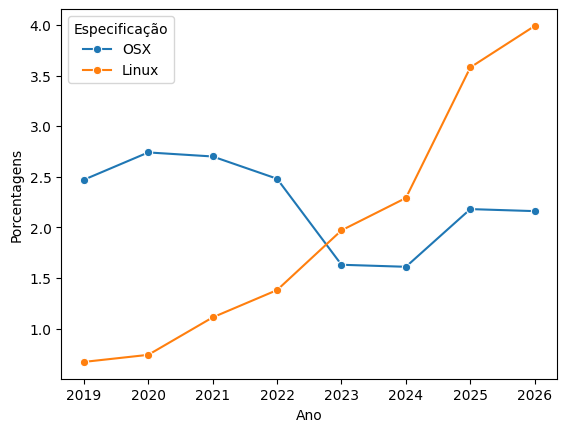

In [30]:
sns.lineplot(data=df_OsVersion, x='Ano', y='Porcentagens', hue='Especificação', marker='o')

#### Correlação entre versões do Windows
Notebook original: `Análise dos dados/Analise de Dados/analiseDados.ipynb`

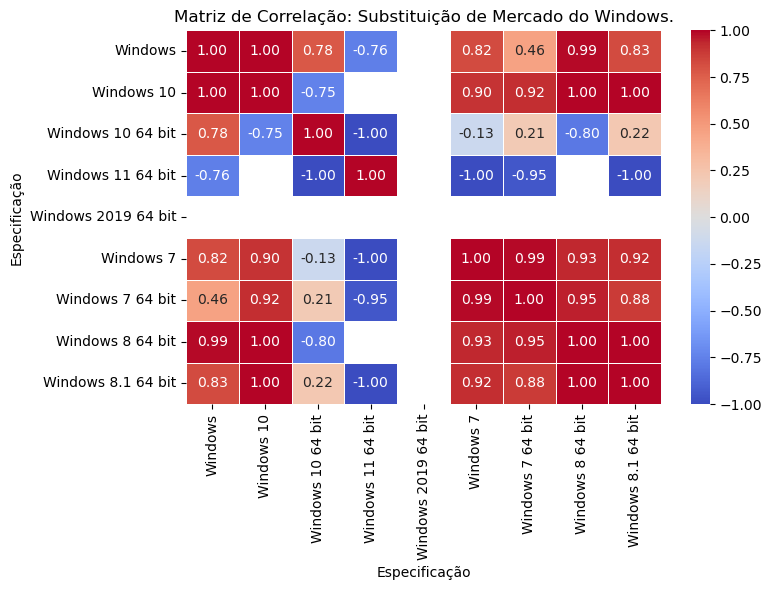

In [16]:
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

df = pd.read_csv(r"CSVs/Dados unidos/dados_anuais_unificado.csv")
categoriaEscolhida = "OS Version"
df_categoria = df[df["Categoria"] == categoriaEscolhida]
df_categoria = df_categoria[df_categoria["Especificação"].str.contains("Windows", na=False)]
matrizDados = df_categoria.pivot(index="Ano", columns="Especificação", values="Porcentagens")
matrizCorrelacao = matrizDados.corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrizCorrelacao, annot=True, fmt=".2f", cmap="coolwarm",vmin=-1, vmax=1, linewidths=0.5)
plt.title(f"Matriz de Correlação: Substituição de Mercado do Windows.")
plt.tight_layout()
plt.show()


### 6. Resolução principal de tela
Análise da evolução mensal das resoluções mais utilizadas pelos usuários da Steam entre janeiro de 2019 e maio de 2026, com uma regressão linear para estimar quando o 2560 × 1440 poderá superar o 1920 × 1080.

Notebook original: `Análise dos dados/analise_monitores.ipynb`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
ORDEM_MESES = {
    "Janeiro": 1, 
    "Fevereiro": 2, 
    "Março": 3, 
    "Abril": 4,
    "Maio": 5, 
    "Junho": 6, 
    "Julho": 7, 
    "Agosto": 8,
    "Setembro": 9, 
    "Outubro": 10, 
    "Novembro": 11, 
    "Dezembro": 12,
}

df = pd.read_csv("CSVs/Dados unidos/dados_mensais_unificado.csv")
df["Porcentagens"] = df["Porcentagens"].str.replace("%", "").astype(float)

df_monitores = df[df["Categoria"] == "Primary Display Resolution"].copy()
df_monitores["Data"] = pd.to_datetime(
    df_monitores["Ano"].astype(str) + "-" + df_monitores["Mês"].map(ORDEM_MESES).astype(str) + "-01"
)

print(f"Linhas: {len(df_monitores)}")
print(f"Resoluções diferentes: {df_monitores['Especificação'].nunique()}")
df_monitores.head()

Linhas: 1585
Resoluções diferentes: 24


,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano,Data
179,Primary Display Resolution,1024 x 768,0.64,0.00%,Janeiro,2019,2019-01-01
180,Primary Display Resolution,1280 x 1024,2.16,+0.03%,Janeiro,2019,2019-01-01
181,Primary Display Resolution,1280 x 720,0.42,0.00%,Janeiro,2019,2019-01-01
182,Primary Display Resolution,1280 x 800,0.82,-0.04%,Janeiro,2019,2019-01-01
183,Primary Display Resolution,1360 x 768,1.95,+0.05%,Janeiro,2019,2019-01-01


In [3]:
print(f"Nulos: {df_monitores['Especificação'].isnull().sum()}")

df_monitores.groupby("Especificação")["Porcentagens"].mean().sort_values(ascending=False).head(10)

Nulos: 0


Especificação
1920 x 1080    61.679326
2560 x 1440    13.037191
1366 x 768      6.287191
3840 x 2160     2.922360
2560 x 1600     2.861500
Other           2.319101
1440 x 900      2.013483
1600 x 900      1.697753
3440 x 1440     1.613483
1680 x 1050     1.191798
Name: Porcentagens, dtype: float64

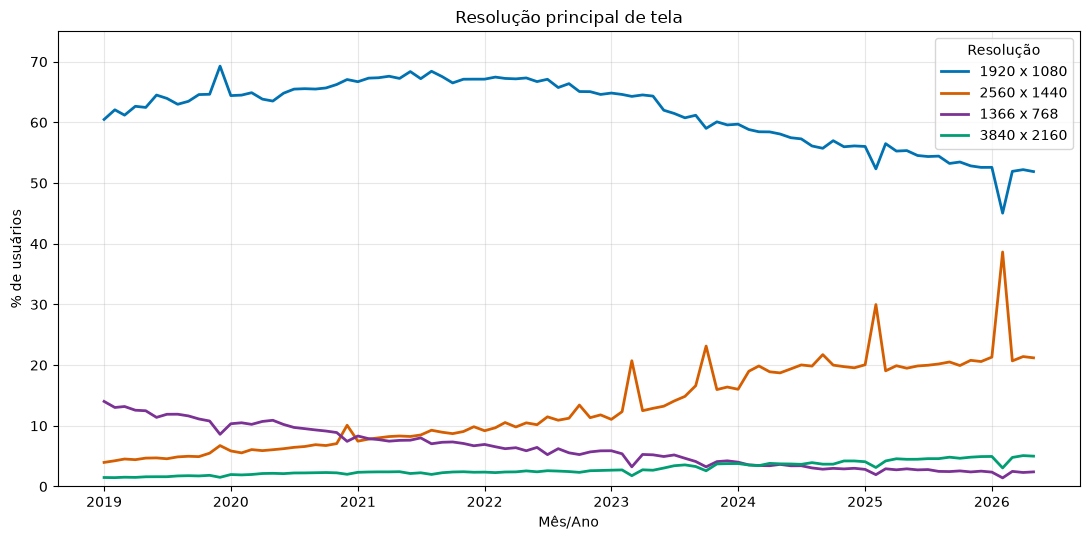

In [4]:
resolucoes = ["1920 x 1080", "2560 x 1440", "1366 x 768", "3840 x 2160"]
cores = {
    "1920 x 1080": "#0072B2",
    "2560 x 1440": "#D55E00",
    "1366 x 768": "#7B3294",
    "3840 x 2160": "#009E73",
}

tabela = df_monitores.pivot_table(index="Data", columns="Especificação", values="Porcentagens") # tranforma na pivot com datas como índice e resoluções como colunas

plt.figure(figsize=(11, 5.5))

for resolucao in resolucoes:
    serie = tabela[resolucao].dropna()
    plt.plot(serie.index, serie, color=cores[resolucao], linewidth=2, label=resolucao)

plt.title("Resolução principal de tela")
plt.xlabel("Mês/Ano")
plt.ylabel("% de usuários")
plt.ylim(0, 75)
plt.legend(title="Resolução")
plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

In [5]:
comparacao = tabela.iloc[[0, -1]][resolucoes].T
comparacao.columns = ["Jan/2019", "Mai/2026"]
comparacao["Diferença"] = (comparacao["Mai/2026"] - comparacao["Jan/2019"]).round(2)
comparacao

,Jan/2019,Mai/2026,Diferença
Especificação,,,
1920 x 1080,60.48,51.89,-8.59
2560 x 1440,3.97,21.20,17.23
1366 x 768,14.02,2.41,-11.61
3840 x 2160,1.48,5.00,3.52


1920 x 1080: -0.346 %/mês | R² = 0.95
2560 x 1440: +0.283 %/mês | R² = 0.65
Interceptação: o 2560 x 1440 ultrapassa o 1920 x 1080 em 10/2029


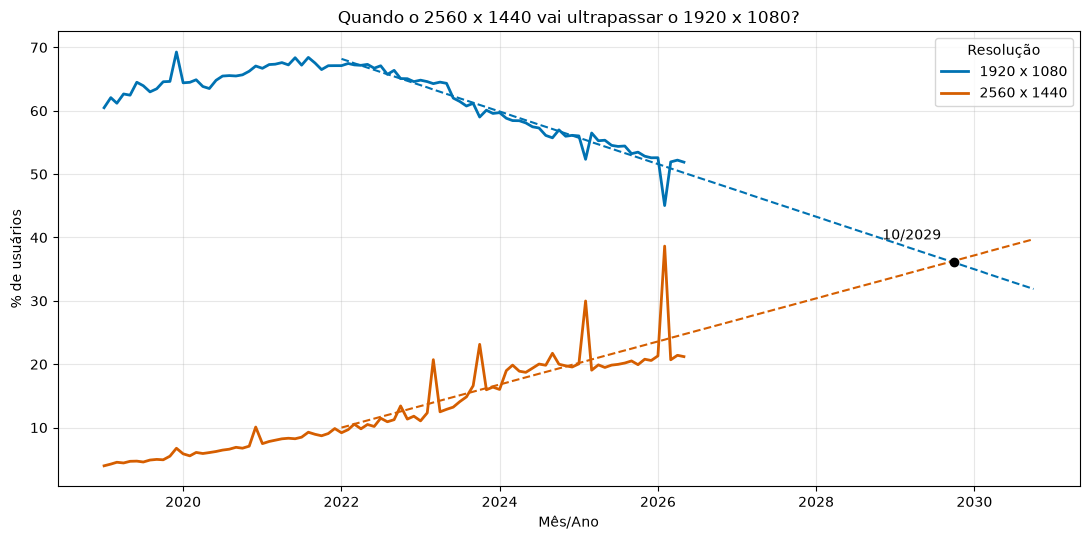

In [ ]:
tendencia = tabela.loc["2022-01-01":, ["1920 x 1080", "2560 x 1440"]] # só a fase de queda: antes de 2022 o 1920 x 1080 ainda estava subindo
X = ((tendencia.index.year - 2022) * 12 + tendencia.index.month - 1).to_numpy().reshape(-1, 1) # a data vira o nº de meses desde Jan/2022

modelo1080 = LinearRegression().fit(X, tendencia["1920 x 1080"])
modelo1440 = LinearRegression().fit(X, tendencia["2560 x 1440"])

mesesAteCruzar = (modelo1080.intercept_ - modelo1440.intercept_) / (modelo1440.coef_[0] - modelo1080.coef_[0]) # a1 + b1x = a2 + b2x
dataCruzamento = pd.Timestamp("2022-01-01") + pd.DateOffset(months=int(round(mesesAteCruzar)))
porcentagemCruzamento = modelo1080.intercept_ + modelo1080.coef_[0] * mesesAteCruzar

print(f"1920 x 1080: {modelo1080.coef_[0]:+.3f} %/mês | R² = {modelo1080.score(X, tendencia['1920 x 1080']):.2f}")
print(f"2560 x 1440: {modelo1440.coef_[0]:+.3f} %/mês | R² = {modelo1440.score(X, tendencia['2560 x 1440']):.2f}")
print(f"Interceptação: o 2560 x 1440 ultrapassa o 1920 x 1080 em {dataCruzamento.strftime('%m/%Y')}")

futuro = pd.date_range("2022-01-01", dataCruzamento + pd.DateOffset(months=12), freq="MS")
X_futuro = ((futuro.year - 2022) * 12 + futuro.month - 1).to_numpy().reshape(-1, 1)

plt.figure(figsize=(11, 5.5))

for resolucao, modelo in [("1920 x 1080", modelo1080), ("2560 x 1440", modelo1440)]:
    plt.plot(tabela[resolucao].dropna(), color=cores[resolucao], linewidth=2, label=resolucao)
    plt.plot(futuro, modelo.predict(X_futuro), color=cores[resolucao], linewidth=1.5, linestyle="--")

plt.plot(dataCruzamento, porcentagemCruzamento, "o", color="black", zorder=5)
plt.annotate(dataCruzamento.strftime("%m/%Y"), xy=(dataCruzamento, porcentagemCruzamento), xytext=(-52, 16), textcoords="offset points")
plt.title("Quando o 2560 x 1440 vai ultrapassar o 1920 x 1080?")
plt.xlabel("Mês/Ano")
plt.ylabel("% de usuários")
plt.legend(title="Resolução")
plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

#### Resultado da análise

O 1920 × 1080 permanece como a resolução principal mais usada, mas sua participação caiu de 60,48% para 51,89% no período analisado. Em sentido oposto, o 2560 × 1440 cresceu de 3,97% para 21,20%, enquanto o 1366 × 768 perdeu espaço e o 3840 × 2160 apresentou crescimento moderado.

Considerando a tendência observada desde 2022, a regressão linear estima que o 2560 × 1440 poderá ultrapassar o 1920 × 1080 por volta de outubro de 2029. Essa projeção indica uma migração gradual dos usuários para resoluções mais altas, embora dependa da continuidade do comportamento atual.

## Relação entre a interpretação dos dados e a Steam Machine (2026)

### Comparação com hardware real: Valve Steam Machine (2026)

Como ponto de referência para as tendências analisadas neste relatório (uso de RAM, versões do Windows/SteamOS, etc.), seguem as especificações oficiais da **Steam Machine**, o console de mesa da Valve lançado em 29/06/2026, cujo hardware foi dimensionado a partir dos próprios dados do Steam Hardware Survey usados nesta análise.

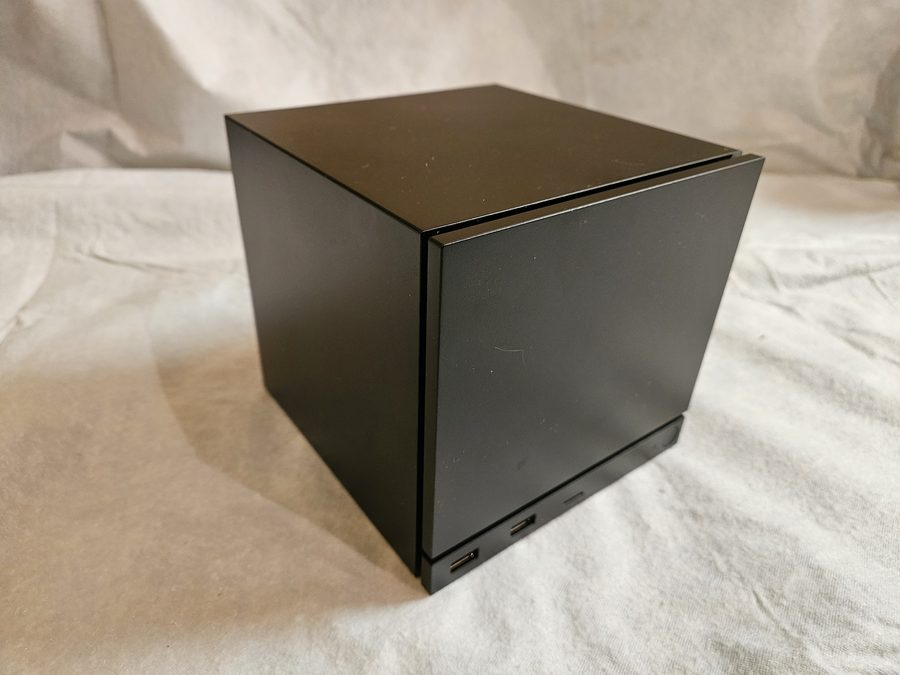

*Foto: Steam Machine (2026), Valve Corporation — via Wikimedia Commons.*

| Especificação | Valor |
|---|---|
| **CPU** | AMD Zen 4 semi-custom, 6 núcleos / 12 threads, até 4.8 GHz, TDP 30 W (aprox. Ryzen 5 7540U) |
| **GPU** | AMD RDNA 3 semi-custom, 28 unidades de computação, clock sustentado de 2.45 GHz, equivalente à Radeon RX 7600M |
| **RAM (System RAM)** | 16 GB DDR5 SO-DIMM (upgradável, 2 slots) |
| **VRAM** | 8 GB GDDR6 |
| **Armazenamento** | 512 GB ou 2 TB NVMe M.2 2230 + slot M.2 2280 de expansão + microSD |
| **Sistema Operacional (OS Version)** | SteamOS 3.x (baseado em Arch Linux) |
| **Conectividade** | Wi-Fi 6E, Bluetooth 5.3, Ethernet Gigabit, DisplayPort 1.4, HDMI 2.0, 4x USB-A, 2x USB-C |
| **Resoluções suportadas** | 720p, 1080p, 1440p e 4K |
| **Dimensões** | 156 × 152 × 162.4 mm |
| **Peso** | 2.6 kg |
| **Preço de lançamento** | US$ 1.049 (512 GB) / US$ 1.349 (2 TB) |

**Relação com os dados analisados:** Os dados analisados permitem concluir que as configurações de hardware utilizadas pela Steam para o lançamento são as mais populares atualmente: 16GB de RAM, 8GB de VRAM, 6 núcleos de CPU o que para jogos ainda é eficiente para a resolução mais popular (1920x1080p). Contudo, um console que visa longevidade pela indisponibilidade de upgrade de hardware conta em partes com especificações modestas se comparadas as análises de tendências para os próximos anos nas categorias mensionadas o que, pelo preço sugerido, põe em cheque como o console lidará com lançamentos em um futuro próximo tendo em vista o aumento do consumo de RAM projetado para 32GB, VRAM para 12GB e 16GB, aumento da resolução para 1440p e jogos que exigirão ao menos 8 núcleos de CPU. Dessa forma, uma análise superficial dos dados colocariam o console como uma excelente configuração por ter a configuração da maioria dos jogadores, enquanto uma análise mais detalhada encontra fragilidades na configuração atual de lançamento do console que mais se assemelha a especificações de consoles lançados em 2020.
Entratando, nem todas as críticas podem ser direcionadas somente à Valve, visto que a crise de chips impactou diretamente o preço final do produto, o tornando menos atrativo e limitando configurações mais robustas como é possível enxergar na análise dos dados de memória RAM que desde o início da crise encontra-se estagnado, a qual é possível atribuir a um aumento nos preços dos chips de mémoria causada pela alta demanda da IA.

Fontes: [Wikipedia - Steam Machine (2026)](https://en.wikipedia.org/wiki/Steam_Machine_(2026)), [Engadget](https://www.engadget.com/gaming/pc/valves-steam-machine-launches-in-2026-everything-we-know-so-far-200458597.html).

## Conclusão

### Resumo das etapas
Este relatório percorreu o pipeline completo do projeto: **Extração** de anos de snapshots mensais do Steam Hardware & Software Survey via web scraping do Wayback Machine; **Leitura** e unificação desses arquivos em bases mensal e anual únicas; **Limpeza** dos valores nulos e das inconsistências de tipo/formatação; e, por fim, os **Gráficos** e modelos estatísticos usados para responder às perguntas propostas na introdução.

### Principais resultados
- **RAM**: os 16 GB se consolidaram como o patamar mais comum de memória desde 2019, mas os 32 GB vêm crescendo de forma constante e, pela regressão linear, devem se aproximar ou ultrapassar os 16 GB por volta de 2030.
- **VRAM**: o agrupamento por K-Means revelou três perfis nítidos de usuário (entrada, intermediário, entusiasta), com a VRAM média subindo de forma consistente em todos os perfis entre 2019 e 2026 — reflexo direto do avanço das GPUs e da demanda de jogos mais pesados.
- **CPU**: o número de núcleos físicos reportados também cresce: 4 núcleos, maioria em 2019, perdeu espaço para 6 e 8 núcleos, tendência que a regressão projeta se acentuar até 2030.
- **Sistema operacional**: o Windows 11 ultrapassou o Windows 10 ao longo de 2025-2026, enquanto o Linux (impulsionado por SteamOS/Steam Deck) mais que quintuplicou sua participação desde 2019, superando o macOS.
- **GPU**: a NVIDIA mantém liderança folgada (~70-85% dos usuários) frente a AMD e Intel, com leve tendência de queda nos últimos anos.
- **Resolução de tela**: o 1920×1080 ainda domina, mas está em queda constante desde 2022, enquanto o 2560×1440 cresce a ponto de a regressão linear apontar um possível cruzamento entre as duas resoluções nos próximos anos.
- **Steam Machine (2026)**: Uma excelente proposta que esbarrou na alta de preço dos chips e entra no mercado de forma pouco promissora na relação custo-benefício.

### Gráficos utilizados
Ao longo do relatório usamos gráficos de **barras** (distribuição de RAM/VRAM por tier, projeções para 2030, participação de fabricantes de GPU), **linhas** (evolução anual e mensal de RAM, CPU, sistema operacional e resolução de tela, com retas de regressão sobrepostas), **dispersão/scatter** (agrupamento K-Means da VRAM, real x previsto das regressões) e **mapa de calor** (correlação entre versões do Windows) — cobrindo mais de três tipos de visualização diferentes.

### Limitações
- A coleta depende da disponibilidade e regularidade dos snapshots no Wayback Machine; alguns meses (ex.: junho de 2020) precisaram ser complementados por uma fonte externa em formato diferente, exigindo padronização manual.
- A pesquisa da Steam é uma amostra voluntária e não necessariamente representativa de todo o universo de jogadores (há viés de idioma, região e adesão voluntária).
- As categorias mudam ao longo do tempo (novas faixas de RAM/VRAM aparecem, outras somem), o que obriga a agrupar valores em "tiers" e pode mascarar mudanças mais finas.
- As regressões lineares usadas são simples (uma reta por categoria) e não capturam saturação de mercado nem mudanças bruscas de tendência (ex.: lançamento de um novo console). Além disso não há influência da coluna Incrementos que necessitaria de uma regressão linear múltipla.

### Trabalhos futuros
- Usar modelos de séries temporais mais robustos (ex.: regressão polinomial) para capturar a saturação de mercado nas projeções.
- Cruzar os dados do Hardware Survey com o calendário de lançamentos de jogos AAA e consoles, testando estatisticamente a relação sugerida na motivação do projeto.
- Cruzar os dados do Hardware Survey com o preço do hardware e sua variação para testar possíveis correlações.